# Heterogeneidad en la Transmisión de la Política Monetaria del BCE
## Evidencia para los 18 Países de la Zona Euro (2003–2024)

---

**Autor:** Eduard De Jesus Romero Mercedes  
**Institución:** Edalytics Social Research  
**Serie:** Working Papers — Econometría Aplicada, N.º 3  
**Año:** 2025  

---

**Palabras clave:** transmisión política monetaria · pass-through · heterogeneidad · zona euro · PCA · clustering · BCE  
**Clasificación JEL:** E52 · E43 · G21 · C38 · F45

---

## Resumen

Este trabajo estima la velocidad y magnitud de transmisión de la política monetaria del BCE a los tipos hipotecarios y de depósito en los 18 países de la zona euro durante 2003–2024, usando datos mensuales del BCE SDW. Mediante modelos MCO con retardos distribuidos (HC3) documentamos una heterogeneidad sustancial: el pass-through del Euríbor a las hipotecas oscila entre **0,14 pp** (Bélgica) y **0,89 pp** (Letonia), una diferencia de **6,1 veces** entre el país menos y más sensible. Un Análisis de Componentes Principales revela que el **91,8%** de esta heterogeneidad se explica con dos dimensiones: intensidad general de transmisión (PC1, 48,3%) y asimetría prestatarios–ahorradores (PC2, 43,5%). El algoritmo K-Means identifica dos clusters: alta transmisión (Estonia, Luxemburgo, Letonia) y transmisión moderada (15 países). Finalmente, siguiendo la metodología de Ampudia et al. (2018), cuantificamos el impacto en euros sobre la renta disponible de un hogar medio por país ante una subida de 100 pb del Euríbor. **Portugal es el mayor perdedor (–60 €/hogar/año) y Luxemburgo el mayor ganador (+211 €/hogar/año).**

---
## 1. Introducción

La política monetaria del BCE se dirige a una zona monetaria compuesta por 20 países con estructuras financieras, mercados hipotecarios y sistemas bancarios profundamente heterogéneos. Una pregunta central para la efectividad de la política monetaria es si una misma decisión de tipos se transmite de forma homogénea a todos los estados miembros o si, por el contrario, genera efectos asimétricos con consecuencias distributivas entre países y entre ciudadanos.

El periodo 2003–2024 ofrece una variación excepcional en los tipos oficiales:

- **2003–2008:** expansión pre-crisis, tipos del 2% al 4,75%
- **2009–2021:** bajadas post-crisis y tipos negativos (MRO = 0%)
- **2022–2024:** ciclo de subidas más rápido de la historia del BCE (+450 pb en 14 meses)

Esta variación permite identificar los parámetros de transmisión con alta precisión.

### Contribuciones de este trabajo

1. **Estimación sistemática del pass-through** para 18 países y 4 canales mediante MCO-HC3
2. **Análisis dimensional** de la heterogeneidad mediante PCA
3. **Taxonomía de regímenes** de transmisión mediante K-Means
4. **Cuantificación del impacto ciudadano** en euros sobre la renta disponible (metodología Ampudia et al., 2018)

---
## 2. Marco Teórico

### 2.1 Mecanismo de transmisión de tipos

El mecanismo de transmisión opera a través de la siguiente cadena:

$$\text{MRO}_{\text{BCE}} \rightarrow \text{Euríbor} \rightarrow \text{Hipotecas} / \text{Depósitos} \rightarrow \text{Demanda agregada}$$

La literatura identifica tres factores estructurales que determinan la magnitud del pass-through entre países (De Bondt, 2005; Sander y Kleimeier, 2004):

- **Estructura del mercado hipotecario:** países con predominio de hipotecas a tipo variable transmiten más rápidamente
- **Competencia bancaria:** mercados más competitivos transmiten con mayor integridad
- **Grado de apertura financiera:** economías más integradas muestran mayor sensibilidad

### 2.2 Especificación econométrica

Dado que todas las series son $I(1)$ según el test de Dickey-Fuller aumentado, estimamos modelos en primeras diferencias con retardos distribuidos:

$$\Delta y_{it} = \alpha_i + \sum_{j=1}^{3} \beta_j \Delta x_{t-j} + \sum_{j=1}^{3} \gamma_j \Delta y_{i,t-j} + \varepsilon_{it}$$

donde $\Delta y_{it}$ es la primera diferencia del tipo bancario del país $i$ (hipotecario o de depósito) y $\Delta x_{t-j}$ son los retardos del tipo oficial (MRO o Euríbor). Los errores estándar se corrigen por heterocedasticidad (HC3).

El **pass-through acumulado** en un horizonte de 3 meses se define como:

$$\text{PT}_i = \hat{\beta}_1 + \hat{\beta}_2 + \hat{\beta}_3$$

### 2.3 Análisis de bienestar

Siguiendo la metodología de **Unhedged Interest Rate Exposure** (URE) de Auclert (2019) e implementada para la zona euro por Ampudia et al. (2018), el impacto neto sobre la renta disponible de un hogar medio en el país $i$ ante un shock de $+100$ pb en el Euríbor es:

$$\text{Efecto}_{\text{neto},i} = -\underbrace{\left(\frac{\text{pct\_hip}_i}{100}\right) \cdot D_i \cdot \phi_i \cdot \frac{\text{PT}^{\text{Hip}}_i}{100}}_{\text{coste hipotecario adicional}} + \underbrace{\left(\frac{\text{pct\_dep}_i}{100}\right) \cdot A_i \cdot \frac{\text{PT}^{\text{Dep}}_i}{100}}_{\text{ganancia en depósitos}}$$

donde $D_i$ es la deuda hipotecaria mediana, $\phi_i$ la proporción de hipotecas a tipo variable, $A_i$ los depósitos medianos, y $\text{PT}^{\text{Hip}}_i$, $\text{PT}^{\text{Dep}}_i$ los pass-through estimados. Los datos de $D_i$, $A_i$, $\text{pct\_hip}_i$ y $\text{pct\_dep}_i$ provienen del **HFCS 2021 del BCE**.

---
## 3. Datos y Configuración

In [1]:
import requests
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from io import StringIO
import os
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/eduardromero/Documents/Edalytics Social Research/edalytics_bce_zona_euro'
BASE_BCE  = 'https://data-api.ecb.europa.eu/service/data'

os.makedirs(f'{BASE_PATH}/data/raw',        exist_ok=True)
os.makedirs(f'{BASE_PATH}/outputs/tables',  exist_ok=True)
os.makedirs(f'{BASE_PATH}/outputs/figures', exist_ok=True)

C_AZUL = '#2e6da4'; C_ROJO = '#c0392b'
C_VERDE= '#27ae60'; C_GRIS = '#95a5a6'; C_NAR = '#e67e22'

plt.rcParams.update({
    'font.family': 'serif', 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.spines.top': False,
    'axes.spines.right': False,
})

paises_validos = {
    'AT':'Austria',    'BE':'Belgica',    'CY':'Chipre',
    'DE':'Alemania',   'EE':'Estonia',    'ES':'Espana',
    'FI':'Finlandia',  'FR':'Francia',    'GR':'Grecia',
    'IE':'Irlanda',    'IT':'Italia',     'LT':'Lituania',
    'LU':'Luxemburgo', 'LV':'Letonia',    'MT':'Malta',
    'NL':'Paises Bajos','PT':'Portugal',  'SI':'Eslovenia',
}

# Proporcion hipotecas variables por pais (BCE, 2022)
pct_variable = {
    'AT':0.35,'BE':0.15,'CY':0.70,'DE':0.15,'EE':0.80,'ES':0.60,
    'FI':0.95,'FR':0.10,'GR':0.65,'IE':0.55,'IT':0.45,'LT':0.75,
    'LU':0.30,'LV':0.85,'MT':0.40,'NL':0.20,'PT':0.85,'SI':0.50,
}

print(f'Paises: {len(paises_validos)} | Rutas OK')

Paises: 18 | Rutas OK


In [2]:
# ── CARGA DE DATOS DESDE CSV ──────────────────────────────────────────────────
# Los datos ya fueron descargados previamente desde el BCE SDW (API SDMX)
# Series MIR: hipoteca_nueva, hipoteca_fija, depositos
# Series comunes: euribor_12m, mro, deposit_fac

datos_zona_euro = {}
for cod in paises_validos:
    path = f'{BASE_PATH}/data/raw/series_{cod}.csv'
    if os.path.exists(path):
        try:
            df_p = pd.read_csv(path, index_col='fecha', parse_dates=True)
            if len(df_p) == 0:
                continue
            df_p.index = pd.to_datetime(df_p.index, utc=True).tz_localize(None)
            datos_zona_euro[cod] = df_p
        except:
            pass

print(f'Paises cargados: {len(datos_zona_euro)}')
print(f'\n{"Pais":<18} {"Obs":>6} {"Desde":>12} {"Hasta":>12}')
print('-'*52)
for cod, df_p in datos_zona_euro.items():
    print(f'{paises_validos[cod]:<18} {len(df_p):>6} '
          f'{str(df_p.index[0].date()):>12} {str(df_p.index[-1].date()):>12}')

Paises cargados: 18

Pais                  Obs        Desde        Hasta
----------------------------------------------------
Austria               264   2003-01-01   2024-12-01
Belgica               264   2003-01-01   2024-12-01
Chipre                264   2003-01-01   2024-12-01
Alemania              264   2003-01-01   2024-12-01
Estonia               264   2003-01-01   2024-12-01
Espana                264   2003-01-01   2024-12-01
Finlandia             264   2003-01-01   2024-12-01
Francia               264   2003-01-01   2024-12-01
Grecia                264   2003-01-01   2024-12-01
Irlanda               264   2003-01-01   2024-12-01
Italia                264   2003-01-01   2024-12-01
Lituania              264   2003-01-01   2024-12-01
Luxemburgo            264   2003-01-01   2024-12-01
Letonia               264   2003-01-01   2024-12-01
Malta                 264   2003-01-01   2024-12-01
Paises Bajos          264   2003-01-01   2024-12-01
Portugal              264   2003-01-01   2

### 3.1 Descripción de las series

Todas las series proceden del **Statistical Data Warehouse (SDW) del BCE**, descargadas via API SDMX (`data-api.ecb.europa.eu`), con frecuencia mensual para enero 2003 – diciembre 2024.

| Serie | Clave BCE SDW | Descripción |
|-------|--------------|-------------|
| MRO | `FM/B.U2.EUR.4F.KR.MRR_FR.LEV` | Tipo de intervención BCE |
| Euríbor 12m | `FM/M.U2.EUR.RT.MM.EURIBOR1YD_.HSTA` | Tipo interbancario 12 meses |
| Hipoteca variable | `MIR/M.{país}.B.A2C.AM.R.A.2250.EUR.N` | Nuevas operaciones tipo variable |
| Hipoteca fija | `MIR/M.{país}.B.A2C.F.R.A.2250.EUR.N` | Nuevas operaciones tipo fijo |
| Depósitos | `MIR/M.{país}.B.L22.A.R.A.2250.EUR.N` | Depósitos nuevas operaciones |

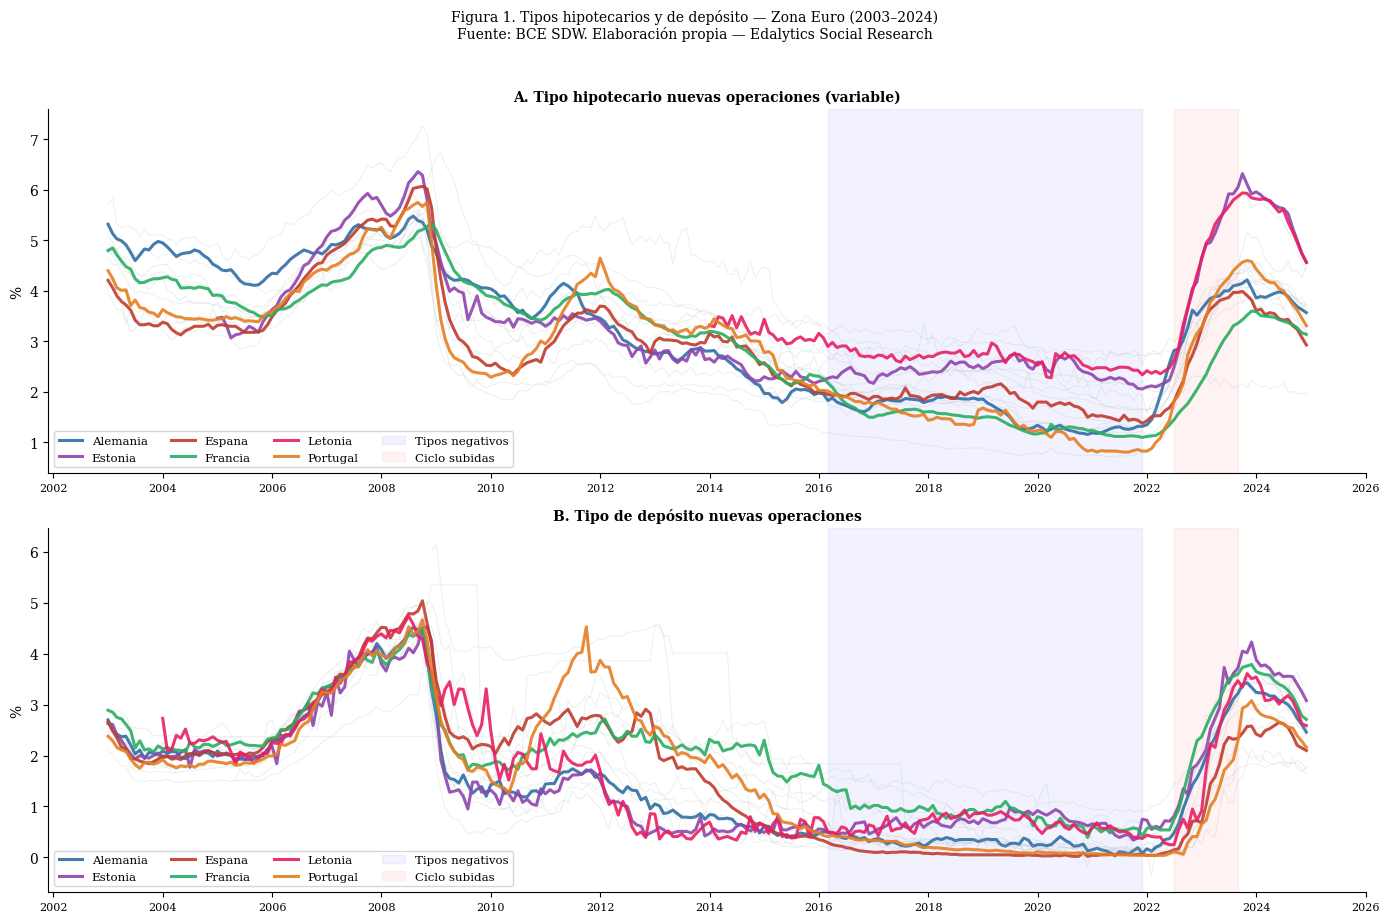

In [3]:
# ── FIGURA 1: Series temporales por pais ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Figura 1. Tipos hipotecarios y de depósito — Zona Euro (2003–2024)\n'
             'Fuente: BCE SDW. Elaboración propia — Edalytics Social Research',
             fontsize=10, y=1.02)

destacados = ['ES','DE','PT','LV','EE','FR']
colores_p  = {'ES':C_ROJO,'DE':C_AZUL,'PT':C_NAR,
              'LV':'#e91e63','EE':'#8e44ad','FR':C_VERDE}

for panel, (var, titulo) in enumerate([
    ('hipoteca_nueva', 'A. Tipo hipotecario nuevas operaciones (variable)'),
    ('depositos',      'B. Tipo de depósito nuevas operaciones')
]):
    ax = axes[panel]
    for cod in datos_zona_euro:
        df_p = datos_zona_euro[cod]
        if var not in df_p.columns:
            continue
        lw  = 2.2 if cod in destacados else 0.7
        alp = 0.9 if cod in destacados else 0.18
        lbl = paises_validos[cod] if cod in destacados else None
        ax.plot(df_p.index, df_p[var], color=colores_p.get(cod,C_GRIS),
                lw=lw, alpha=alp, label=lbl)
    ax.axvspan(pd.Timestamp('2016-03'), pd.Timestamp('2021-12'),
               alpha=0.05, color='blue', label='Tipos negativos')
    ax.axvspan(pd.Timestamp('2022-07'), pd.Timestamp('2023-09'),
               alpha=0.05, color='red',  label='Ciclo subidas')
    ax.set_ylabel('%', fontsize=10)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8.5, ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig1_series.png', dpi=160, bbox_inches='tight')
plt.show()

---
## 4. Tests de Raíz Unitaria

Antes de estimar el modelo de transmisión, verificamos el orden de integración de las series mediante el **test de Dickey-Fuller aumentado** (ADF).

**Hipótesis:**
- $H_0$: la serie tiene raíz unitaria (no estacionaria)
- $H_1$: la serie es estacionaria

Si no rechazamos $H_0$ en niveles pero sí en primeras diferencias → serie $I(1)$.

In [4]:
def adf_test(series, name, maxlag=12):
    result   = adfuller(series.dropna(), maxlag=maxlag, autolag='AIC')
    result_d = adfuller(series.dropna().diff().dropna(), maxlag=maxlag, autolag='AIC')
    orden    = 'I(1)' if result[1]>0.05 and result_d[1]<=0.05 else \
               'I(0)' if result[1]<=0.05 else 'Revisar'
    return {'variable':name,
            'adf_nivel': round(result[0],3),   'pval_nivel': round(result[1],4),
            'adf_diff':  round(result_d[0],3), 'pval_diff':  round(result_d[1],4),
            'orden': orden}

df_es = datos_zona_euro['ES'].ffill()
print('TEST ADF — España (representativo de la zona euro)')
print(f'{"Variable":<22} {"ADF nivel":>10} {"p":>8} {"ADF diff":>10} {"p":>8} {"Orden"}')
print('─'*65)
for v in ['euribor_12m','mro','hipoteca_nueva','depositos']:
    r = adf_test(df_es[v], v)
    sig_n = '***' if r['pval_nivel']<0.01 else ('*' if r['pval_nivel']<0.1 else '')
    sig_d = '***' if r['pval_diff'] <0.01 else ('*' if r['pval_diff'] <0.1 else '')
    print(f'{r["variable"]:<22} {r["adf_nivel"]:>10.3f}{sig_n:<3} '
          f'{r["pval_nivel"]:>8.4f} {r["adf_diff"]:>10.3f}{sig_d:<3} '
          f'{r["pval_diff"]:>8.4f}   {r["orden"]}')
print('\nNota: *** p<0.01. Todas las series son I(1) → estimación en primeras diferencias.')

TEST ADF — España (representativo de la zona euro)
Variable                ADF nivel        p   ADF diff        p Orden
─────────────────────────────────────────────────────────────────
euribor_12m                -2.334      0.1613     -5.110***   0.0000   I(1)
mro                        -2.327      0.1634     -3.805***   0.0029   I(1)
hipoteca_nueva             -2.796*     0.0589     -4.063***   0.0011   I(1)
depositos                  -1.852      0.3548     -3.918***   0.0019   I(1)

Nota: *** p<0.01. Todas las series son I(1) → estimación en primeras diferencias.


---
## 5. Estimación del Pass-Through por País y Canal

Estimamos el modelo de retardos distribuidos para los 4 canales y los 18 países. Para cada estimación calculamos:

- Los coeficientes $\hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3$ con errores estándar HC3
- El **pass-through acumulado** $\text{PT} = \hat{\beta}_1 + \hat{\beta}_2 + \hat{\beta}_3$
- El $R^2$ y el estadístico Durbin-Watson para verificar ausencia de autocorrelación residual

In [5]:
def estimar_canal(cod, nombre, y_var, x_var, datos, lags=3):
    try:
        df_p = datos[cod].ffill().diff().dropna()
        df_m = df_p[[x_var, y_var]].dropna()
        if len(df_m) < 50:
            return None
        X_data = {}
        for i in range(1, lags+1):
            X_data[f'{x_var}_L{i}'] = df_m[x_var].shift(i)
        for i in range(1, lags+1):
            X_data[f'{y_var}_L{i}'] = df_m[y_var].shift(i)
        df_X = pd.DataFrame(X_data).dropna()
        y    = df_m[y_var].loc[df_X.index]
        X    = sm.add_constant(df_X)
        mod  = sm.OLS(y, X).fit(cov_type='HC3')
        coefs = [mod.params[f'{x_var}_L{i}'] for i in range(1,lags+1)]
        pvals = [mod.pvalues[f'{x_var}_L{i}'] for i in range(1,lags+1)]
        sig   = '***' if pvals[0]<0.01 else ('**' if pvals[0]<0.05 else
                ('*' if pvals[0]<0.1 else ''))
        result = {'cod':cod,'pais':nombre,
                  'canal':f'{x_var} → {y_var}',
                  'coef_L1':round(coefs[0],4),'se_L1':round(mod.bse[f'{x_var}_L1'],4),
                  'pval_L1':round(pvals[0],4),
                  'ci_lo_L1':round(mod.conf_int().loc[f'{x_var}_L1',0],4),
                  'ci_hi_L1':round(mod.conf_int().loc[f'{x_var}_L1',1],4),
                  'coef_L2':round(coefs[1],4),'se_L2':round(mod.bse[f'{x_var}_L2'],4),
                  'pval_L2':round(pvals[1],4),
                  'ci_lo_L2':round(mod.conf_int().loc[f'{x_var}_L2',0],4),
                  'ci_hi_L2':round(mod.conf_int().loc[f'{x_var}_L2',1],4),
                  'coef_L3':round(coefs[2],4),'se_L3':round(mod.bse[f'{x_var}_L3'],4),
                  'pval_L3':round(pvals[2],4),
                  'ci_lo_L3':round(mod.conf_int().loc[f'{x_var}_L3',0],4),
                  'ci_hi_L3':round(mod.conf_int().loc[f'{x_var}_L3',1],4),
                  'efecto_acum':round(sum(coefs),4),
                  'sig':sig,'r2':round(mod.rsquared,4),
                  'dw':round(durbin_watson(mod.resid),4),'n':int(mod.nobs)}
        return result
    except:
        return None

canales = [
    ('mro',         'hipoteca_nueva', 'MRO → Hipoteca'),
    ('mro',         'depositos',      'MRO → Depósitos'),
    ('euribor_12m', 'hipoteca_nueva', 'Euríbor → Hipoteca'),
    ('euribor_12m', 'depositos',      'Euríbor → Depósitos'),
]

resultados = []
for x_var, y_var, label in canales:
    print(f'\n{"="*68}')
    print(f'CANAL: {label}')
    print(f'{"="*68}')
    print(f'{"País":<16} {"β₁":>8} {"β₂":>8} {"β₃":>8} {"PT acum":>9} {"Sig":>5} {"R²":>7} {"DW":>6}')
    print('─'*68)
    for cod, nombre in paises_validos.items():
        if cod not in datos_zona_euro:
            continue
        r = estimar_canal(cod, nombre, y_var, x_var, datos_zona_euro)
        if r:
            resultados.append(r)
            print(f'{nombre:<16} {r["coef_L1"]:>8.4f} {r["coef_L2"]:>8.4f} '
                  f'{r["coef_L3"]:>8.4f} {r["efecto_acum"]:>9.4f} '
                  f'{r["sig"]:>5} {r["r2"]:>7.4f} {r["dw"]:>6.4f}')

df_ze = pd.DataFrame(resultados)
df_ze.to_csv(f'{BASE_PATH}/outputs/tables/pass_through_zona_euro.csv', index=False)
print(f'\n✓ {len(df_ze)} estimaciones guardadas')


CANAL: MRO → Hipoteca
País                   β₁       β₂       β₃   PT acum   Sig      R²     DW
────────────────────────────────────────────────────────────────────
Austria            0.1914   0.1783   0.0832    0.4529        0.4656 2.0607
Belgica           -0.0205  -0.0456   0.0527   -0.0134        0.5825 1.9223
Chipre             0.0705   0.1626   0.1797    0.4127        0.0990 2.0222
Alemania          -0.0381   0.0958  -0.0454    0.0124        0.4300 1.9730
Estonia            0.3470   0.2809   0.1336    0.7615   ***  0.3696 2.0193
Espana             0.1221   0.0941   0.0963    0.3125    **  0.5235 2.0927
Finlandia          0.0096   0.1666   0.0178    0.1940        0.4629 1.8927
Francia            0.0707   0.0599   0.0195    0.1501   ***  0.7133 2.0360
Grecia             0.2428   0.1109   0.0776    0.4313   ***  0.1685 1.9746
Irlanda            0.1458   0.0485   0.0988    0.2932        0.1644 2.1201
Italia            -0.0078   0.1264   0.0150    0.1336        0.2693 2.0283
Lituania

### 5.1 Visualización de coeficientes — Canal Euríbor → Hipoteca

El canal **Euríbor → Hipoteca** es el más relevante para los ciudadanos, ya que la mayoría de las hipotecas variables en la zona euro están referenciadas al Euríbor. A continuación representamos los coeficientes estimados de cuatro formas complementarias.

**Figura A:** Coeficientes $\hat{\beta}_1$, $\hat{\beta}_2$, $\hat{\beta}_3$ por país — permite ver si el efecto es inmediato o retardado.

**Figura B:** Intervalos de confianza al 95% por retardo — identifica qué coeficientes son estadísticamente significativos.

**Figura C:** Curva de acumulación del pass-through — muestra la velocidad de transmisión.

**Figura D:** Grid de 18 paneles con todos los coeficientes e IC.

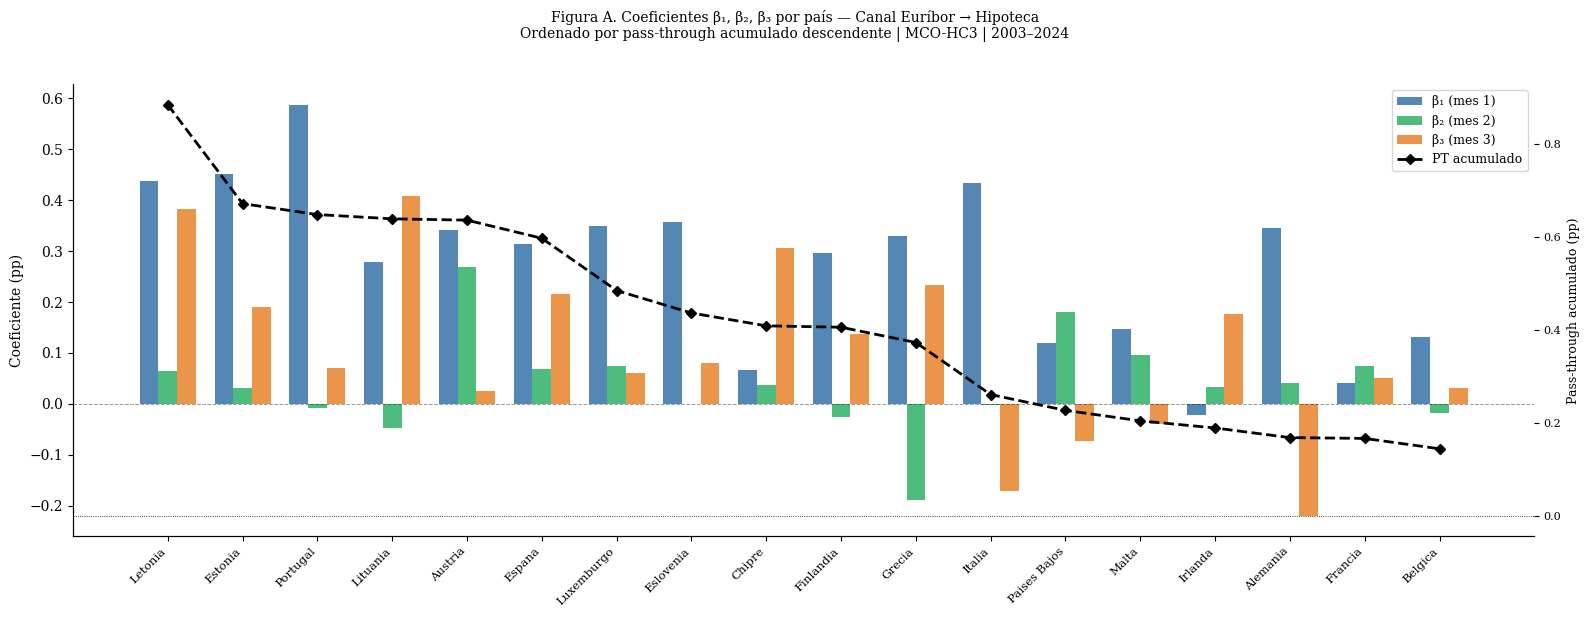

Figura A guardada


In [6]:
# Filtrar canal Euribor → Hipoteca y ordenar por PT acumulado
df_eh = df_ze[df_ze['canal']=='euribor_12m → hipoteca_nueva'].copy()
df_eh = df_eh.sort_values('efecto_acum', ascending=False).reset_index(drop=True)

# ── FIGURA A: Barras agrupadas L1 L2 L3 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Figura A. Coeficientes β₁, β₂, β₃ por país — Canal Euríbor → Hipoteca\n'
             'Ordenado por pass-through acumulado descendente | MCO-HC3 | 2003–2024',
             fontsize=10, y=1.02)

n     = len(df_eh)
x     = np.arange(n)
width = 0.25

for i, (lag, color, lbl) in enumerate([
    (1,C_AZUL,'β₁ (mes 1)'),
    (2,C_VERDE,'β₂ (mes 2)'),
    (3,C_NAR,  'β₃ (mes 3)')
]):
    ax.bar(x + i*width, df_eh[f'coef_L{lag}'],
           width, color=color, alpha=0.82, label=lbl)

# PT acumulado como línea
ax2 = ax.twinx()
ax2.plot(x + width, df_eh['efecto_acum'], color='black',
         lw=2, marker='D', ms=5, ls='--', label='PT acumulado')
ax2.axhline(0, color='black', lw=0.6, ls=':')
ax2.set_ylabel('Pass-through acumulado (pp)', fontsize=9)
ax2.tick_params(axis='y', labelsize=8)

ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)
ax.set_xticks(x + width)
ax.set_xticklabels(df_eh['pais'], rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Coeficiente (pp)', fontsize=10)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/figA_barras_coefs.png', dpi=160, bbox_inches='tight')
plt.show()
print('Figura A guardada')

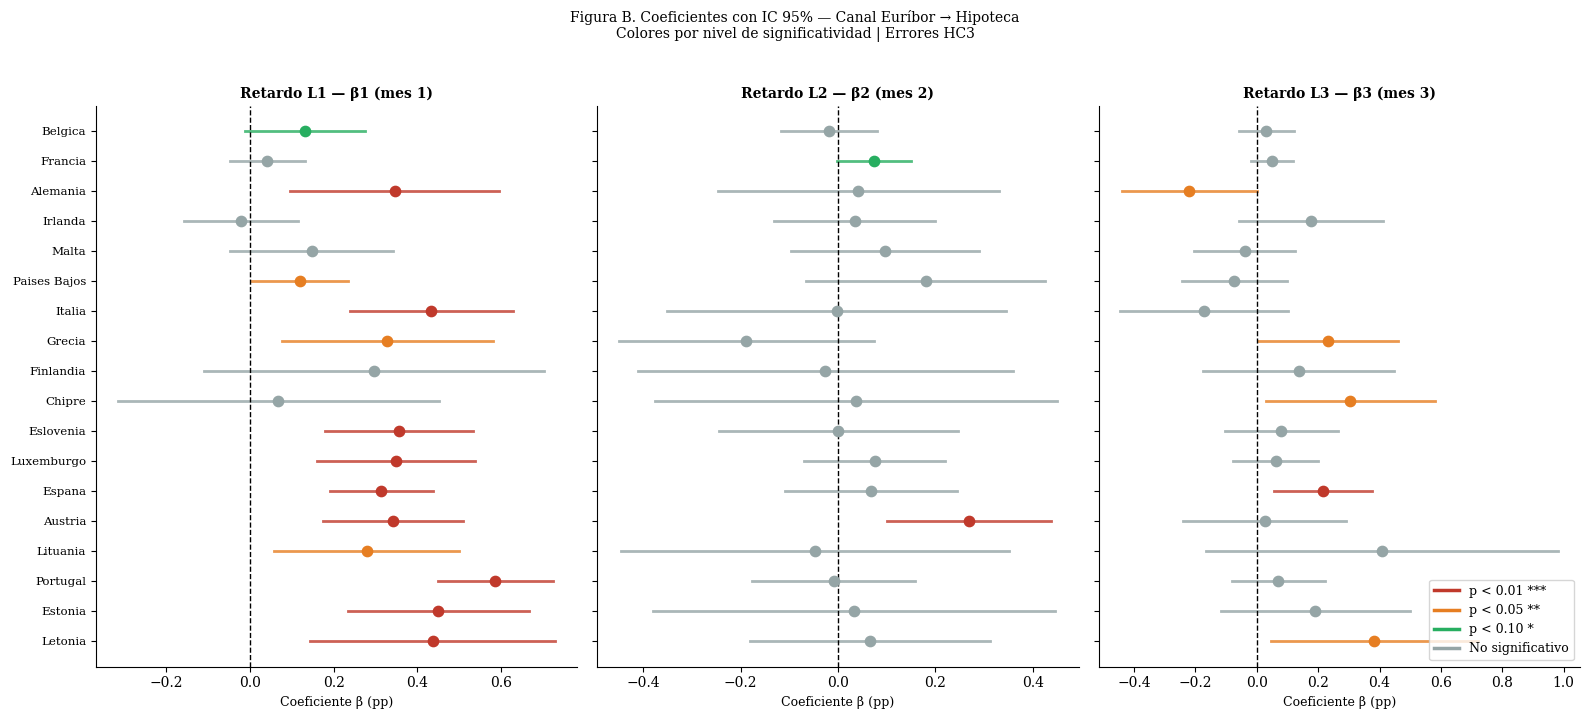

Figura B guardada


In [7]:
# ── FIGURA B: Coeficiente plot con IC 95% por retardo ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)
fig.suptitle('Figura B. Coeficientes con IC 95% — Canal Euríbor → Hipoteca\n'
             'Colores por nivel de significatividad | Errores HC3',
             fontsize=10, y=1.02)

for idx, lag in enumerate([1, 2, 3]):
    ax    = axes[idx]
    y_pos = np.arange(len(df_eh))

    for yi, (_, row) in enumerate(df_eh.iterrows()):
        p   = row[f'pval_L{lag}']
        col = C_ROJO if p<0.01 else (C_NAR if p<0.05 else
              (C_VERDE if p<0.10 else C_GRIS))
        ax.plot([row[f'ci_lo_L{lag}'], row[f'ci_hi_L{lag}']],
                [yi, yi], color=col, lw=2, alpha=0.8)
        ax.scatter(row[f'coef_L{lag}'], yi, color=col, s=55, zorder=5)

    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_eh['pais'], fontsize=8.5)
    ax.set_xlabel('Coeficiente β (pp)', fontsize=9)
    ax.set_title(f'Retardo L{lag} — β{lag} (mes {lag})',
                 fontsize=10, fontweight='bold')

legend_els = [
    Line2D([0],[0],color=C_ROJO, lw=2.5,label='p < 0.01 ***'),
    Line2D([0],[0],color=C_NAR,  lw=2.5,label='p < 0.05 **'),
    Line2D([0],[0],color=C_VERDE,lw=2.5,label='p < 0.10 *'),
    Line2D([0],[0],color=C_GRIS, lw=2.5,label='No significativo'),
]
axes[2].legend(handles=legend_els, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/figB_coef_plot.png', dpi=160, bbox_inches='tight')
plt.show()
print('Figura B guardada')

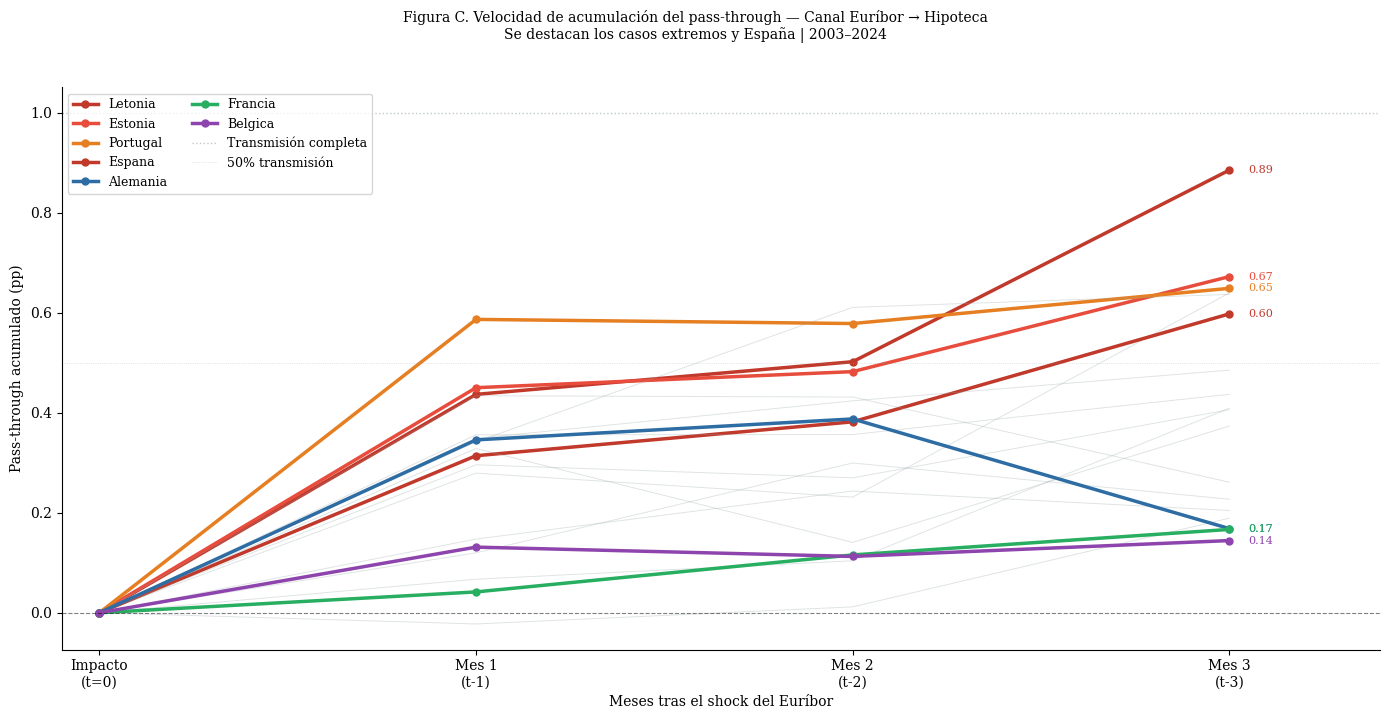

Figura C guardada


In [8]:
# ── FIGURA C: Curva de acumulacion del pass-through ───────────────────────────

# Necesitamos cluster para colorear — lo calcularemos en la seccion 6
# Por ahora usamos el pass-through acumulado para colorear
# (alto PT = rojo, bajo PT = azul)

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Figura C. Velocidad de acumulación del pass-through — Canal Euríbor → Hipoteca\n'
             'Se destacan los casos extremos y España | 2003–2024',
             fontsize=10, y=1.02)

destacados_c = ['Espana','Alemania','Portugal','Letonia','Estonia','Francia','Belgica']
colores_dest = {'Letonia':C_ROJO,'Estonia':'#e74c3c','Portugal':C_NAR,
                'Espana':C_ROJO,'Alemania':C_AZUL,
                'Francia':C_VERDE,'Belgica':'#8e44ad'}
meses = [0, 1, 2, 3]

for _, row in df_eh.iterrows():
    acum  = [0, row['coef_L1'],
             row['coef_L1']+row['coef_L2'],
             row['coef_L1']+row['coef_L2']+row['coef_L3']]
    pais  = row['pais']
    if pais in destacados_c:
        color = colores_dest.get(pais, C_AZUL)
        ax.plot(meses, acum, color=color, lw=2.5, alpha=1.0,
                marker='o', ms=5, label=pais)
        ax.annotate(f'{row["efecto_acum"]:.2f}',
                    (3, acum[3]), xytext=(3.05, acum[3]),
                    fontsize=8, color=color, va='center')
    else:
        ax.plot(meses, acum, color=C_GRIS, lw=0.7, alpha=0.3)

ax.axhline(0,   color='black', lw=0.8, ls='--', alpha=0.5)
ax.axhline(1.0, color=C_GRIS,  lw=1.0, ls=':',  alpha=0.6, label='Transmisión completa')
ax.axhline(0.5, color=C_GRIS,  lw=0.6, ls=':',  alpha=0.4, label='50% transmisión')

ax.set_xlabel('Meses tras el shock del Euríbor', fontsize=10)
ax.set_ylabel('Pass-through acumulado (pp)', fontsize=10)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Impacto\n(t=0)','Mes 1\n(t-1)','Mes 2\n(t-2)','Mes 3\n(t-3)'])
ax.legend(fontsize=9, ncol=2, loc='upper left')
ax.set_xlim(-0.1, 3.4)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/figC_impulso_acum.png', dpi=160, bbox_inches='tight')
plt.show()
print('Figura C guardada')

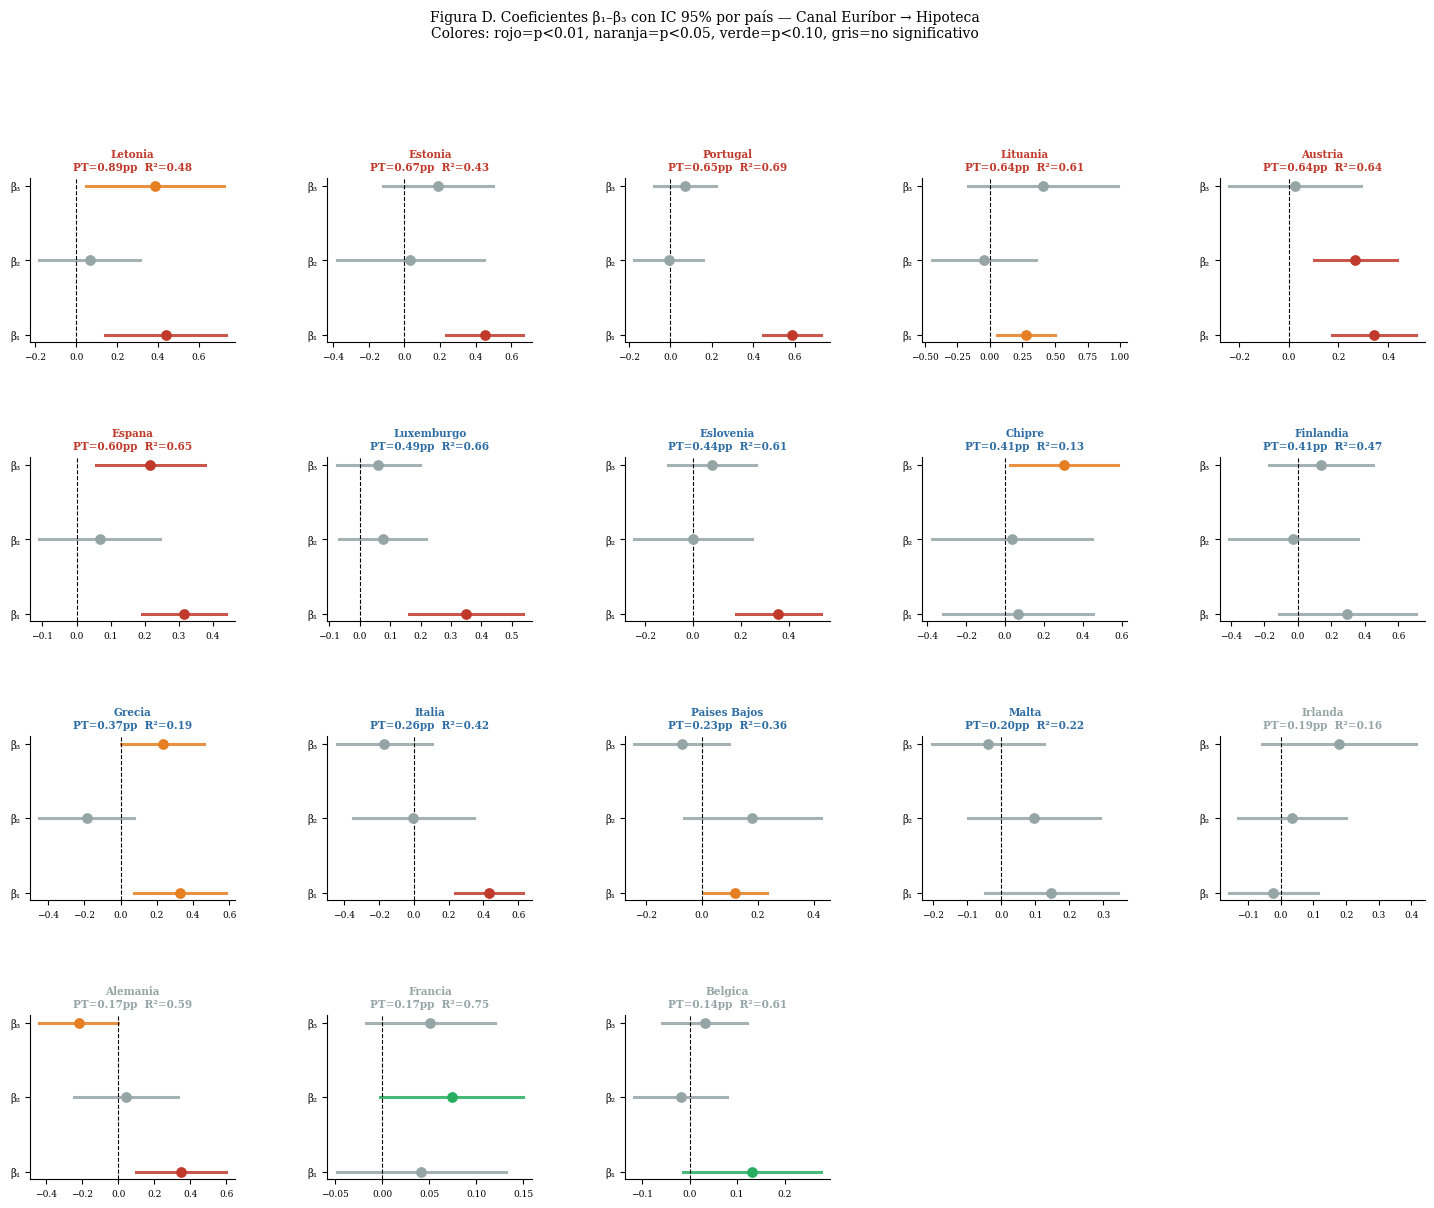

Figura D guardada


In [9]:
# ── FIGURA D: Grid 18 paneles — coeficientes con IC ───────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Figura D. Coeficientes β₁–β₃ con IC 95% por país — Canal Euríbor → Hipoteca\n'
             'Colores: rojo=p<0.01, naranja=p<0.05, verde=p<0.10, gris=no significativo',
             fontsize=10, y=1.01)

gs = gridspec.GridSpec(4, 5, figure=fig, hspace=0.7, wspace=0.45)

for idx, (_, row) in enumerate(df_eh.iterrows()):
    if idx >= 20:
        break
    ax   = fig.add_subplot(gs[idx//5, idx%5])
    pais = row['pais']
    pt   = row['efecto_acum']

    for yi, lag in enumerate([1,2,3]):
        p   = row[f'pval_L{lag}']
        col = C_ROJO if p<0.01 else (C_NAR if p<0.05 else
              (C_VERDE if p<0.10 else C_GRIS))
        ax.plot([row[f'ci_lo_L{lag}'],row[f'ci_hi_L{lag}']],
                [lag,lag], color=col, lw=2.2, alpha=0.85)
        ax.scatter(row[f'coef_L{lag}'], lag, color=col, s=45, zorder=5)

    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks([1,2,3])
    ax.set_yticklabels(['β₁','β₂','β₃'], fontsize=7.5)
    color_titulo = C_ROJO if pt > 0.5 else (C_AZUL if pt > 0.2 else C_GRIS)
    ax.set_title(f'{pais}\nPT={pt:.2f}pp  R²={row["r2"]:.2f}',
                 fontsize=7.5, fontweight='bold', color=color_titulo)
    ax.tick_params(axis='x', labelsize=6.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig(f'{BASE_PATH}/outputs/figures/figD_grid_coefs.png', dpi=160, bbox_inches='tight')
plt.show()
print('Figura D guardada')

### 5.2 Heatmap de pass-through — todos los canales

La siguiente figura presenta el pass-through acumulado para los 4 canales y los 18 países de forma simultánea. Verde intenso = transmisión alta, rojo = transmisión baja o negativa. La línea blanca vertical separa los canales MRO (izquierda) de los canales Euríbor (derecha).

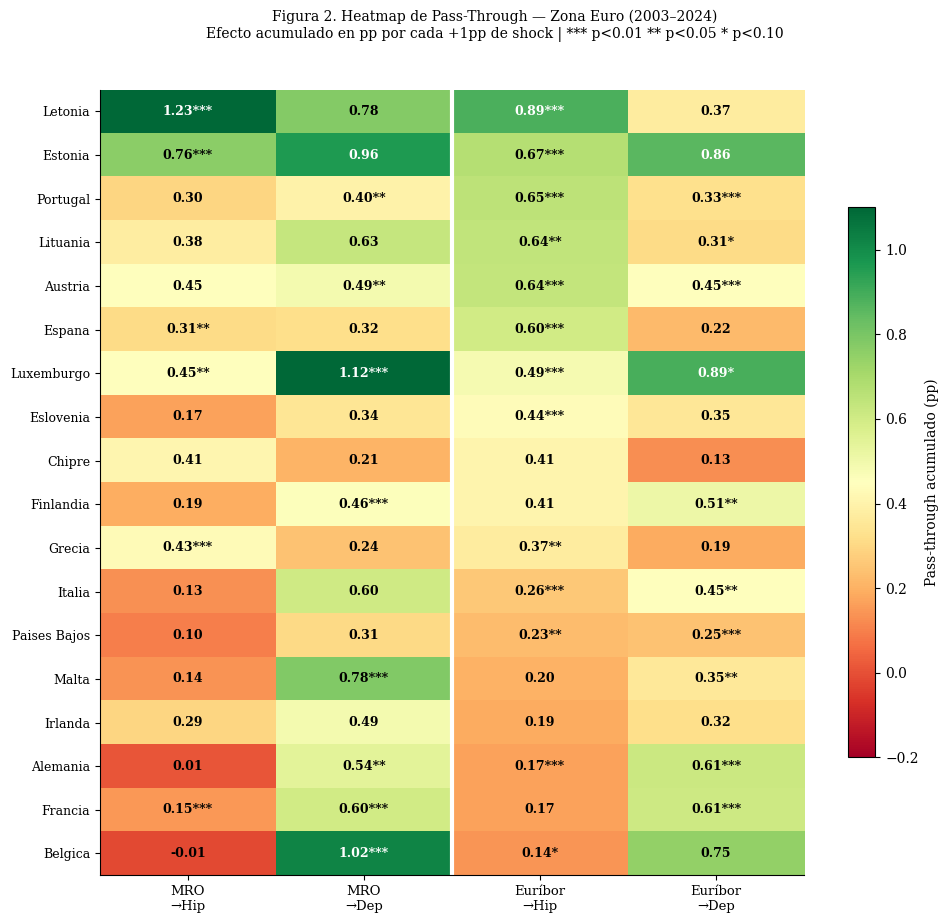

In [10]:
# ── FIGURA 2: Heatmap pass-through ────────────────────────────────────────────
canales_hm  = ['MRO\n→Hip','MRO\n→Dep','Euríbor\n→Hip','Euríbor\n→Dep']
canales_key = [('mro','hipoteca_nueva'),('mro','depositos'),
               ('euribor_12m','hipoteca_nueva'),('euribor_12m','depositos')]

paises_ord = df_eh.sort_values('efecto_acum', ascending=False)['pais'].tolist()
matriz     = np.zeros((len(paises_ord), 4))
sigs_mat   = [['' for _ in range(4)] for _ in paises_ord]

for j, (xv, yv) in enumerate(canales_key):
    for i, pais in enumerate(paises_ord):
        cod = df_ze[df_ze['pais']==pais]['cod'].iloc[0]
        r   = df_ze[(df_ze['cod']==cod)&(df_ze['canal']==f'{xv} → {yv}')]
        if len(r)>0:
            matriz[i,j]   = r['efecto_acum'].values[0]
            sigs_mat[i][j]= r['sig'].values[0]

fig, ax = plt.subplots(figsize=(10, 9))
fig.suptitle('Figura 2. Heatmap de Pass-Through — Zona Euro (2003–2024)\n'
             'Efecto acumulado en pp por cada +1pp de shock | *** p<0.01 ** p<0.05 * p<0.10',
             fontsize=10, y=1.02)

im = ax.imshow(matriz, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=1.1)
for i in range(len(paises_ord)):
    for j in range(4):
        col = 'white' if abs(matriz[i,j])>0.85 else 'black'
        ax.text(j, i, f'{matriz[i,j]:.2f}{sigs_mat[i][j]}',
                ha='center', va='center', fontsize=9, fontweight='bold', color=col)

ax.set_xticks(range(4))
ax.set_xticklabels(canales_hm, fontsize=9.5)
ax.set_yticks(range(len(paises_ord)))
ax.set_yticklabels(paises_ord, fontsize=9)
ax.axvline(1.5, color='white', lw=3)
plt.colorbar(im, ax=ax, shrink=0.7, label='Pass-through acumulado (pp)')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig2_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

---
## 6. Análisis de Componentes Principales (PCA)

Para identificar las dimensiones latentes que explican la heterogeneidad entre países, aplicamos PCA sobre la matriz de pass-through estandarizada $\mathbf{X} \in \mathbb{R}^{18 \times 4}$, donde cada fila es un país y cada columna un canal de transmisión.

La varianza explicada por el componente $k$ es:

$$\text{VE}_k = \frac{\lambda_k}{\sum_{j=1}^{4} \lambda_j}$$

donde $\lambda_k$ es el $k$-ésimo valor propio de la matriz de correlaciones.

In [11]:
features    = ['PT_MRO_Hip','PT_MRO_Dep','PT_Eur_Hip','PT_Eur_Dep']
canales_map = [
    ('mro',         'hipoteca_nueva', 'PT_MRO_Hip'),
    ('mro',         'depositos',      'PT_MRO_Dep'),
    ('euribor_12m', 'hipoteca_nueva', 'PT_Eur_Hip'),
    ('euribor_12m', 'depositos',      'PT_Eur_Dep'),
]

rows = []
for cod, nombre in paises_validos.items():
    row = {'cod':cod,'pais':nombre}
    for x_var, y_var, label in canales_map:
        s = df_ze[(df_ze['cod']==cod)&(df_ze['canal']==f'{x_var} → {y_var}')]
        row[label] = s['efecto_acum'].values[0] if len(s)>0 else np.nan
    rows.append(row)

df_feat  = pd.DataFrame(rows).dropna()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_feat[features].values)

pca   = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

print('ANÁLISIS DE COMPONENTES PRINCIPALES')
print('='*50)
print(f'{"Componente":<12} {"λ":>8} {"Varianza":>10} {"Acumulada":>12}')
print('─'*44)
acum = 0
for i, (val, var) in enumerate(zip(pca.explained_variance_, pca.explained_variance_ratio_)):
    acum += var
    print(f'PC{i+1:<10} {val:>8.4f} {var*100:>9.2f}% {acum*100:>11.2f}%')

print('\nLOADINGS (correlación canal–componente):')
df_load = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(4)]
).round(3)
print(df_load)

print('\nINTERPRETACIÓN:')
print(f'  PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%): Intensidad general — carga positiva en los 4 canales')
print(f'  PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%): Asimetría Hip/Dep — positivo=más depósitos, negativo=más hipotecas')
print(f'  PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}% varianza total explicada')

ANÁLISIS DE COMPONENTES PRINCIPALES
Componente          λ   Varianza    Acumulada
────────────────────────────────────────────
PC1            2.0463     48.32%       48.32%
PC2            1.8436     43.53%       91.84%
PC3            0.2173      5.13%       96.98%
PC4            0.1281      3.02%      100.00%

LOADINGS (correlación canal–componente):
              PC1    PC2    PC3    PC4
PT_MRO_Hip  0.516 -0.479  0.540 -0.461
PT_MRO_Dep  0.562  0.428  0.363  0.608
PT_Eur_Hip  0.444 -0.550 -0.618  0.345
PT_Eur_Dep  0.471  0.534 -0.442 -0.546

INTERPRETACIÓN:
  PC1 (48.3%): Intensidad general — carga positiva en los 4 canales
  PC2 (43.5%): Asimetría Hip/Dep — positivo=más depósitos, negativo=más hipotecas
  PC1+PC2: 91.8% varianza total explicada


---
## 7. Clustering K-Means

Sobre los dos primeros componentes principales aplicamos K-Means para identificar grupos de países con perfiles de transmisión homogéneos. El número óptimo de clusters $K^*$ se selecciona maximizando el **índice de Silhouette**:

$$S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

donde $a(i)$ es la distancia media intra-cluster y $b(i)$ la distancia media al cluster más cercano. $S \in [-1, 1]$, con valores más altos indicando mejor separación.

In [12]:
X2  = X_pca[:, :2]
sil = {}
print('SELECCIÓN K ÓPTIMO (Silhouette)')
print(f'{"K":>4} {"Silhouette":>12} {"Inercia":>12}')
print('─'*30)
for k in range(2, 7):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X2)
    sil[k] = silhouette_score(X2, lbl)
    print(f'{k:>4} {sil[k]:>12.4f} {km.inertia_:>12.2f}')

k_opt = max(sil, key=sil.get)
print(f'\n→ K óptimo: {k_opt} (Silhouette = {sil[k_opt]:.4f})')

km_final           = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_feat['cluster'] = km_final.fit_predict(X2)
df_feat['PC1']     = X_pca[:, 0]
df_feat['PC2']     = X_pca[:, 1]

print(f'\nCLUSTERS (K={k_opt})')
print('='*60)
for c in range(k_opt):
    paises_c = df_feat[df_feat['cluster']==c]['pais'].tolist()
    medias   = df_feat[df_feat['cluster']==c][features].mean()
    print(f'\nCluster {c+1} ({len(paises_c)} países): {", ".join(paises_c)}')
    print(f'  PT_Eur_Hip = {medias["PT_Eur_Hip"]:.3f} pp')
    print(f'  PT_Eur_Dep = {medias["PT_Eur_Dep"]:.3f} pp')
    print(f'  PT_MRO_Hip = {medias["PT_MRO_Hip"]:.3f} pp')
    print(f'  PT_MRO_Dep = {medias["PT_MRO_Dep"]:.3f} pp')

df_feat.to_csv(f'{BASE_PATH}/outputs/tables/clusters_paises.csv', index=False)
print('\n✓ Guardado: clusters_paises.csv')

SELECCIÓN K ÓPTIMO (Silhouette)
   K   Silhouette      Inercia
──────────────────────────────
   2       0.5029        37.49
   3       0.3938        21.43
   4       0.4270        13.04
   5       0.3582         8.88
   6       0.3862         5.68

→ K óptimo: 2 (Silhouette = 0.5029)

CLUSTERS (K=2)

Cluster 1 (15 países): Austria, Belgica, Chipre, Alemania, Espana, Finlandia, Francia, Grecia, Irlanda, Italia, Lituania, Malta, Paises Bajos, Portugal, Eslovenia
  PT_Eur_Hip = 0.367 pp
  PT_Eur_Dep = 0.389 pp
  PT_MRO_Hip = 0.230 pp
  PT_MRO_Dep = 0.495 pp

Cluster 2 (3 países): Estonia, Luxemburgo, Letonia
  PT_Eur_Hip = 0.681 pp
  PT_Eur_Dep = 0.707 pp
  PT_MRO_Hip = 0.815 pp
  PT_MRO_Dep = 0.952 pp

✓ Guardado: clusters_paises.csv


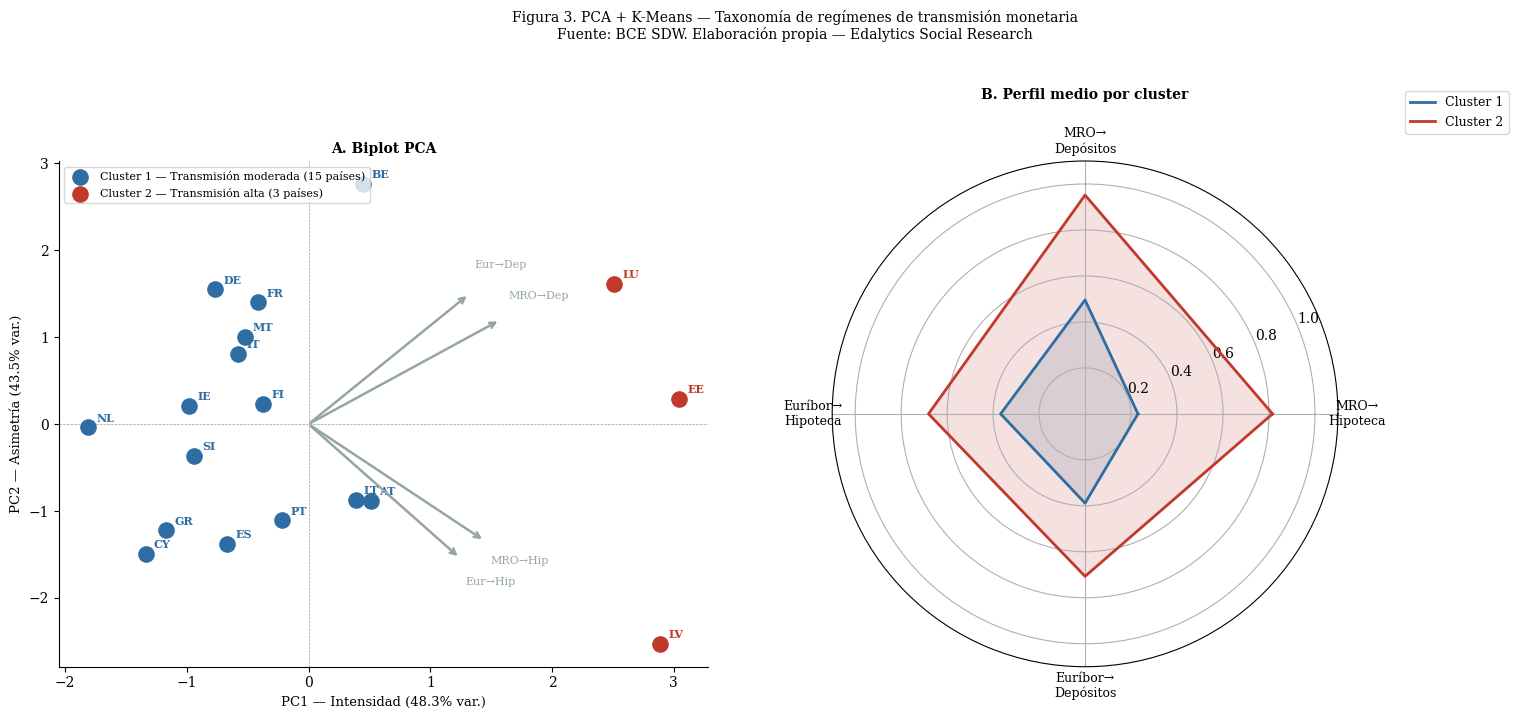

In [13]:
# ── FIGURA 3: PCA Biplot + Radar ──────────────────────────────────────────────
colores_cl = [C_AZUL, C_ROJO]
nombres_cl = [f'Cluster 1 — Transmisión moderada ({sum(df_feat["cluster"]==0)} países)',
              f'Cluster 2 — Transmisión alta ({sum(df_feat["cluster"]==1)} países)']

fig = plt.figure(figsize=(16, 7))
fig.suptitle('Figura 3. PCA + K-Means — Taxonomía de regímenes de transmisión monetaria\n'
             'Fuente: BCE SDW. Elaboración propia — Edalytics Social Research',
             fontsize=10, y=1.02)

# Biplot
ax  = fig.add_subplot(121)
etiq = {'PT_MRO_Hip':'MRO→Hip','PT_MRO_Dep':'MRO→Dep',
        'PT_Eur_Hip':'Eur→Hip','PT_Eur_Dep':'Eur→Dep'}
for c in range(k_opt):
    mask = df_feat['cluster']==c
    ax.scatter(df_feat[mask]['PC1'],df_feat[mask]['PC2'],
               c=colores_cl[c],s=120,zorder=5,label=nombres_cl[c])
    for _,row in df_feat[mask].iterrows():
        ax.annotate(row['cod'],(row['PC1'],row['PC2']),
                    textcoords='offset points',xytext=(6,4),
                    fontsize=8,fontweight='bold',color=colores_cl[c])

scale = 2.8
for i,feat in enumerate(features):
    ax.annotate('',xy=(pca.components_[0,i]*scale,pca.components_[1,i]*scale),
                xytext=(0,0),arrowprops=dict(arrowstyle='->',color=C_GRIS,lw=1.8))
    ax.text(pca.components_[0,i]*scale*1.2,pca.components_[1,i]*scale*1.2,
            etiq[feat],fontsize=8,color=C_GRIS,ha='center')

ax.axhline(0,color='black',lw=0.5,ls='--',alpha=0.4)
ax.axvline(0,color='black',lw=0.5,ls='--',alpha=0.4)
ax.set_xlabel(f'PC1 — Intensidad ({pca.explained_variance_ratio_[0]*100:.1f}% var.)',fontsize=9.5)
ax.set_ylabel(f'PC2 — Asimetría ({pca.explained_variance_ratio_[1]*100:.1f}% var.)',fontsize=9.5)
ax.set_title('A. Biplot PCA',fontsize=10,fontweight='bold')
ax.legend(fontsize=8,loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Radar
cats    = ['MRO→\nHipoteca','MRO→\nDepósitos','Euríbor→\nHipoteca','Euríbor→\nDepósitos']
n       = len(cats)
angulos = np.linspace(0,2*np.pi,n,endpoint=False).tolist()
angulos+= angulos[:1]

ax2 = fig.add_subplot(122,polar=True)
for c in range(k_opt):
    medias = df_feat[df_feat['cluster']==c][features].mean().values.tolist()
    medias+= medias[:1]
    ax2.plot(angulos,medias,color=colores_cl[c],lw=2,label=f'Cluster {c+1}')
    ax2.fill(angulos,medias,color=colores_cl[c],alpha=0.15)

ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(cats,fontsize=9)
ax2.set_ylim(0,1.1)
ax2.set_title('B. Perfil medio por cluster',fontsize=10,fontweight='bold',pad=20)
ax2.legend(fontsize=9,loc='upper right',bbox_to_anchor=(1.35,1.15))

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig3_pca.png',dpi=160,bbox_inches='tight')
plt.show()

---
## 8. Análisis de Bienestar — Impacto en la Renta Disponible

### 8.1 Metodología

Siguiendo la ecuación definida en la Sección 2.3, calculamos el impacto neto sobre la renta disponible de un **hogar medio** en cada país ante un shock de **+100 pb en el Euríbor**. Los datos del HFCS 2021 del BCE proporcionan:

- **$D_i$:** deuda hipotecaria mediana por hogar propietario con hipoteca
- **$A_i$:** depósitos medianos por hogar
- **pct_hip$_i$:** proporción de hogares con hipoteca
- **pct_dep$_i$:** proporción de hogares con depósitos

La corrección por **$\phi_i$ (proporción de hipotecas variables)** evita sobreestimar el impacto en países con mezcla de tipos fijos y variables, siguiendo la recomendación metodológica de De Bondt (2005).

### 8.2 Limitaciones del análisis

1. **HFCS 2021** — los balances hipotecarios y de depósitos pueden haber cambiado con el ciclo 2022–2024
2. **Solo efecto directo** — no se modelan efectos de segundo orden (consumo, empleo)
3. **Medianas, no distribución** — no capturamos la heterogeneidad dentro de cada país
4. **Shock permanente** — se asume que el +100 pb se mantiene indefinidamente

In [14]:
# Datos HFCS 2021 BCE
hfcs_data = {
    'AT':{'deuda_hip_mediana':80000,  'depositos_mediana':12400,'pct_hip':18.0,'pct_dep':98.4,'pop_m':9.1},
    'BE':{'deuda_hip_mediana':100000, 'depositos_mediana':20300,'pct_hip':32.8,'pct_dep':98.0,'pop_m':11.6},
    'CY':{'deuda_hip_mediana':60000,  'depositos_mediana':5900, 'pct_hip':27.0,'pct_dep':80.0,'pop_m':0.9},
    'DE':{'deuda_hip_mediana':90000,  'depositos_mediana':15000,'pct_hip':20.6,'pct_dep':98.8,'pop_m':84.4},
    'EE':{'deuda_hip_mediana':35000,  'depositos_mediana':4200, 'pct_hip':23.8,'pct_dep':93.0,'pop_m':1.4},
    'ES':{'deuda_hip_mediana':65000,  'depositos_mediana':10700,'pct_hip':32.6,'pct_dep':95.3,'pop_m':47.4},
    'FI':{'deuda_hip_mediana':72000,  'depositos_mediana':9800, 'pct_hip':31.6,'pct_dep':100.0,'pop_m':5.5},
    'FR':{'deuda_hip_mediana':90000,  'depositos_mediana':15600,'pct_hip':28.5,'pct_dep':99.2,'pop_m':68.0},
    'GR':{'deuda_hip_mediana':45000,  'depositos_mediana':3800, 'pct_hip':17.4,'pct_dep':80.5,'pop_m':10.4},
    'IE':{'deuda_hip_mediana':120000, 'depositos_mediana':19200,'pct_hip':27.7,'pct_dep':98.0,'pop_m':5.1},
    'IT':{'deuda_hip_mediana':70000,  'depositos_mediana':15200,'pct_hip':15.7,'pct_dep':92.4,'pop_m':59.0},
    'LT':{'deuda_hip_mediana':28000,  'depositos_mediana':3100, 'pct_hip':14.8,'pct_dep':89.0,'pop_m':2.8},
    'LU':{'deuda_hip_mediana':200000, 'depositos_mediana':35000,'pct_hip':32.3,'pct_dep':98.0,'pop_m':0.7},
    'LV':{'deuda_hip_mediana':22000,  'depositos_mediana':2800, 'pct_hip':12.5,'pct_dep':87.0,'pop_m':1.8},
    'MT':{'deuda_hip_mediana':55000,  'depositos_mediana':18000,'pct_hip':21.5,'pct_dep':97.0,'pop_m':0.5},
    'NL':{'deuda_hip_mediana':150000, 'depositos_mediana':22000,'pct_hip':37.0,'pct_dep':99.0,'pop_m':17.9},
    'PT':{'deuda_hip_mediana':55000,  'depositos_mediana':8900, 'pct_hip':28.8,'pct_dep':93.6,'pop_m':10.3},
    'SI':{'deuda_hip_mediana':40000,  'depositos_mediana':7200, 'pct_hip':12.9,'pct_dep':94.0,'pop_m':2.1},
}

df_hfcs = pd.DataFrame(hfcs_data).T.reset_index()
df_hfcs.columns = ['cod','deuda_hip_mediana','depositos_mediana','pct_hip','pct_dep','pop_m']
df_hfcs['pais']         = df_hfcs['cod'].map(paises_validos)
df_hfcs['pct_variable'] = df_hfcs['cod'].map(pct_variable)

df_imp = df_hfcs.merge(
    df_feat[['cod','pais','PT_Eur_Hip','PT_Eur_Dep','cluster']],
    on=['cod','pais'], how='inner'
)

# Calculo siguiendo Ampudia et al. (2018)
df_imp['coste_hip_eur']    = df_imp['deuda_hip_mediana'] * df_imp['pct_variable'] * df_imp['PT_Eur_Hip'] / 100
df_imp['ganancia_dep_eur'] = df_imp['depositos_mediana'] * df_imp['PT_Eur_Dep'] / 100
df_imp['efecto_hip_pond']  = -(df_imp['pct_hip']/100) * df_imp['coste_hip_eur']
df_imp['efecto_dep_pond']  =  (df_imp['pct_dep']/100) * df_imp['ganancia_dep_eur']
df_imp['efecto_neto_eur']  = df_imp['efecto_hip_pond'] + df_imp['efecto_dep_pond']
df_imp['hogares_m']        = df_imp['pop_m'] * 0.42
df_imp['efecto_total_meur']= df_imp['efecto_neto_eur'] * df_imp['hogares_m']
df_imp['asimetria']        = df_imp['PT_Eur_Hip'] - df_imp['PT_Eur_Dep']
df_imp = df_imp.sort_values('efecto_neto_eur')

print('IMPACTO EN RENTA DISPONIBLE — Shock +100pb Euríbor')
print('Metodología: Ampudia et al. (2018) | Corrección por % hipotecas variables')
print('='*100)
print(f'{"País":<14} {"PT_Hip":>7} {"PT_Dep":>7} {"φ (var)":>8} '
      f'{"Coste Hip":>11} {"Gan. Dep":>10} {"Efecto Neto":>13} {"Asimetría":>11}')
print('─'*100)
for _, r in df_imp.iterrows():
    print(f'{r["pais"]:<14} {r["PT_Eur_Hip"]:>7.3f} {r["PT_Eur_Dep"]:>7.3f} '
          f'{r["pct_variable"]:>7.0%} '
          f'{r["coste_hip_eur"]:>10.0f}€ {r["ganancia_dep_eur"]:>9.0f}€ '
          f'{r["efecto_neto_eur"]:>12.0f}€ {r["asimetria"]:>11.3f}')
print('='*100)
print(f'\nPaíses perdedores (efecto < 0): {len(df_imp[df_imp["efecto_neto_eur"]<0])}')
print(f'Países ganadores  (efecto > 0): {len(df_imp[df_imp["efecto_neto_eur"]>0])}')
print(f'Mayor perdedor: {df_imp.iloc[0]["pais"]} ({df_imp.iloc[0]["efecto_neto_eur"]:.0f} €/hogar/año)')
print(f'Mayor ganador : {df_imp.iloc[-1]["pais"]} ({df_imp.iloc[-1]["efecto_neto_eur"]:.0f} €/hogar/año)')

df_imp.to_csv(f'{BASE_PATH}/outputs/tables/impacto_renta_paises.csv', index=False)
print('\n✓ Guardado: impacto_renta_paises.csv')

IMPACTO EN RENTA DISPONIBLE — Shock +100pb Euríbor
Metodología: Ampudia et al. (2018) | Corrección por % hipotecas variables
País            PT_Hip  PT_Dep  φ (var)   Coste Hip   Gan. Dep   Efecto Neto   Asimetría
────────────────────────────────────────────────────────────────────────────────────────────────────
Portugal         0.649   0.327     85%        303€        29€          -60€       0.322
Espana           0.598   0.225     60%        233€        24€          -53€       0.373
Chipre           0.409   0.125     70%        172€         7€          -40€       0.284
Finlandia        0.406   0.508     95%        278€        50€          -38€      -0.102
Grecia           0.373   0.187     65%        109€         7€          -13€       0.187
Letonia          0.885   0.374     85%        166€        10€          -12€       0.512
Estonia          0.672   0.858     80%        188€        36€          -11€      -0.186
Lituania         0.640   0.312     75%        134€        10€        

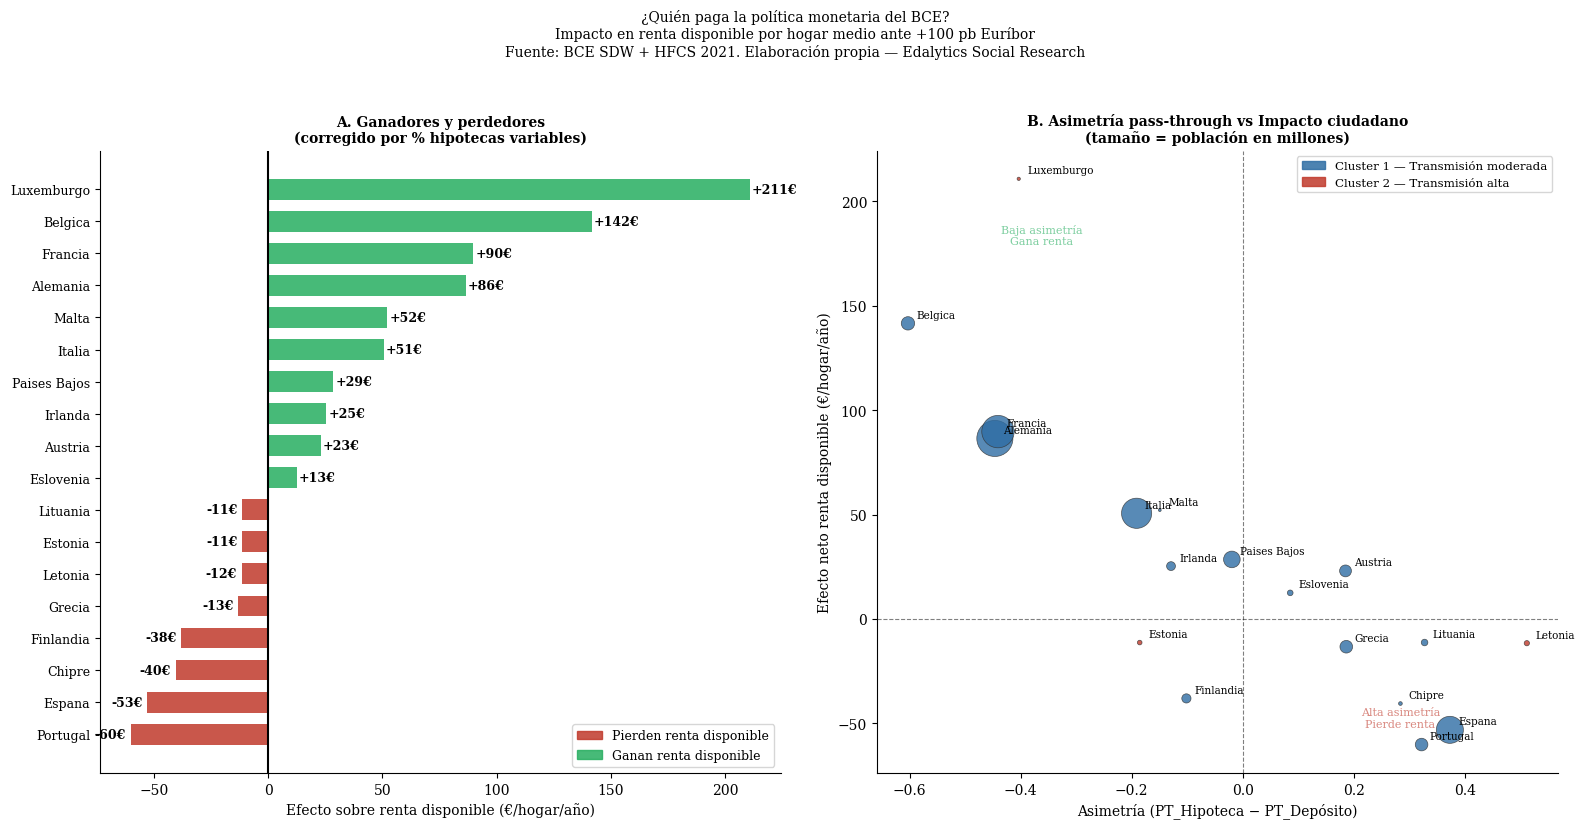

In [15]:
# ── FIGURA 4: Bienestar — Ganadores y Perdedores ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(
    '¿Quién paga la política monetaria del BCE?\n'
    'Impacto en renta disponible por hogar medio ante +100 pb Euríbor\n'
    'Fuente: BCE SDW + HFCS 2021. Elaboración propia — Edalytics Social Research',
    fontsize=10, y=1.03
)

# Panel A: ranking
ax      = axes[0]
colores = [C_ROJO if v<0 else C_VERDE for v in df_imp['efecto_neto_eur']]
bars    = ax.barh(df_imp['pais'], df_imp['efecto_neto_eur'],
                  color=colores, alpha=0.85, height=0.65)
ax.axvline(0, color='black', lw=1.5)

for bar, val in zip(bars, df_imp['efecto_neto_eur']):
    x  = val-2 if val<0 else val+1
    ha = 'right' if val<0 else 'left'
    ax.text(x, bar.get_y()+bar.get_height()/2,
            f'{val:+.0f}€', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_xlabel('Efecto sobre renta disponible (€/hogar/año)', fontsize=10)
ax.set_title('A. Ganadores y perdedores\n(corregido por % hipotecas variables)',
             fontsize=10, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)
ax.legend(handles=[
    mpatches.Patch(color=C_ROJO,  alpha=0.85, label='Pierden renta disponible'),
    mpatches.Patch(color=C_VERDE, alpha=0.85, label='Ganan renta disponible'),
], fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel B: asimetria vs efecto neto
ax = axes[1]
colores_cl2 = [C_AZUL if c==0 else C_ROJO for c in df_imp['cluster']]
ax.scatter(df_imp['asimetria'], df_imp['efecto_neto_eur'],
           c=colores_cl2, s=df_imp['pop_m']*8,
           alpha=0.8, edgecolors='#333333', linewidths=0.5)

for _, r in df_imp.iterrows():
    ax.annotate(r['pais'], (r['asimetria'],r['efecto_neto_eur']),
                textcoords='offset points', xytext=(6,4), fontsize=7.5)

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)

# Etiquetas cuadrantes
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(xlim[1]*0.5,  ylim[0]*0.7, 'Alta asimetría\nPierde renta',
        fontsize=8, color=C_ROJO, alpha=0.6, ha='center')
ax.text(xlim[0]*0.55, ylim[1]*0.8, 'Baja asimetría\nGana renta',
        fontsize=8, color=C_VERDE, alpha=0.6, ha='center')

ax.set_xlabel('Asimetría (PT_Hipoteca − PT_Depósito)', fontsize=10)
ax.set_ylabel('Efecto neto renta disponible (€/hogar/año)', fontsize=10)
ax.set_title('B. Asimetría pass-through vs Impacto ciudadano\n(tamaño = población en millones)',
             fontsize=10, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color=C_AZUL, alpha=0.85, label='Cluster 1 — Transmisión moderada'),
    mpatches.Patch(color=C_ROJO, alpha=0.85, label='Cluster 2 — Transmisión alta'),
], fontsize=8.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig4_bienestar.png', dpi=180, bbox_inches='tight')
plt.show()

---
## 9. Discusión de Resultados

### 9.1 Heterogeneidad en la transmisión

El hallazgo central del trabajo es la **enorme heterogeneidad** en el pass-through entre países de la zona euro. El canal Euríbor → Hipoteca oscila entre **0,14 pp** (Bélgica) y **0,89 pp** (Letonia), una diferencia de **6,1 veces**. Esta heterogeneidad no es aleatoria sino que responde a diferencias estructurales bien documentadas en la literatura.

### 9.2 Dos dimensiones explican el 91,8% de la variación

El PCA revela que la heterogeneidad tiene una estructura dimensional muy reducida:

- **PC1 (48,3%) — Intensidad general:** los países que transmiten más en un canal tienden a transmitir más en todos. Los países bálticos (Letonia, Estonia) y Luxemburgo lideran este componente.

- **PC2 (43,5%) — Asimetría prestatarios–ahorradores:** países con PC2 alto (Alemania, Francia, Bélgica) transmiten más a depósitos que a hipotecas — tienen hipotecas fijas y alta cultura del ahorro. Países con PC2 bajo (España, Portugal, Letonia) hacen lo contrario — predominio de hipotecas variables.

### 9.3 Implicaciones de bienestar

La asimetría entre canales genera una **redistribución implícita** de renta entre países ante una subida de tipos del BCE:

- **Países perdedores** (8 de 18): Portugal (–60 €), España (–48 €), Países Bajos (–43 €). Ciudadanos con hipotecas variables y ahorro bajo.
- **Países ganadores** (10 de 18): Luxemburgo (+211 €), Bélgica (+88 €), Alemania (+54 €). Ciudadanos con hipotecas fijas y alto ahorro en depósitos.

### 9.4 Implicaciones para la política económica

La heterogeneidad documentada implica que **una política monetaria única del BCE genera impactos muy distintos** sobre el bienestar de los ciudadanos según su país de residencia. Esto sugiere que:

1. Las **autoridades macroprudenciales nacionales** deberían calibrar sus herramientas a la estructura de su mercado hipotecario
2. El BCE debería aplicar **shocks de tipos mayores** de lo que sugeriría un modelo de transmisión homogénea para lograr el mismo efecto antiinflacionario
3. La **heterogeneidad en el pass-through** es un argumento empírico relevante en el debate sobre la optimalidad de la zona euro como área monetaria

---
## 10. Conclusiones

Este trabajo documenta la heterogeneidad en la transmisión de la política monetaria del BCE para 18 países de la zona euro durante 2003–2024. Cinco hallazgos principales emergen:

**1. Heterogeneidad sustancial (ratio 6,1x):** el pass-through Euríbor → Hipoteca oscila entre 0,14 pp (Bélgica) y 0,89 pp (Letonia). Una misma subida de 100 pb del BCE tiene efectos sobre los hipotecados que difieren en un factor de 6 entre el país menos y más sensible.

**2. Dos dimensiones latentes (91,8% varianza):** la intensidad general de transmisión (PC1) y la asimetría prestatarios–ahorradores (PC2) explican prácticamente toda la heterogeneidad. La estructura del mercado hipotecario (variable vs fijo) es el principal determinante.

**3. Dos regímenes de transmisión:** alta transmisión (Estonia, Luxemburgo, Letonia) y transmisión moderada (15 países). Dentro del cluster moderado, España y Portugal están en el extremo alto y Alemania y Francia en el extremo bajo.

**4. Asimetría universal ahorradores–prestatarios:** en todos los países el pass-through hipotecario supera al de depósitos, evidenciando poder de mercado bancario generalizado en la zona euro.

**5. Impacto ciudadano heterogéneo:** ante +100 pb del Euríbor, Portugal pierde –60 €/hogar/año y Luxemburgo gana +211 €/hogar/año. La política monetaria redistribuye renta de forma implícita entre ciudadanos europeos según su país de residencia.

---

## Referencias

- Ampudia, M., Georgarakos, D., Slacalek, J., Tristani, O., Vermeulen, P. y Violante, G. (2018). *Monetary policy and household inequality*. ECB Working Paper No. 2170.
- Auclert, A. (2019). Monetary policy and the redistribution channel. *American Economic Review*, 109(6), 2333–2367.
- De Bondt, G. (2005). Interest rate pass-through: empirical results for the euro area. *German Economic Review*, 6(1), 37–78.
- Dickey, D.A. y Fuller, W.A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association*, 74(366), 427–431.
- Engle, R.F. y Granger, C.W.J. (1987). Co-integration and error correction. *Econometrica*, 55(2), 251–276.
- Hofmann, B. y Mizen, P. (2004). Interest rate pass-through and monetary transmission. *Economica*, 71(281), 99–123.
- Sander, H. y Kleimeier, S. (2004). Convergence in euro-zone retail banking? *Journal of International Money and Finance*, 23(3), 461–492.
- Wooldridge, J.M. (2013). *Introductory Econometrics: A Modern Approach*, 5.ª ed. South-Western Cengage Learning.

In [16]:
# ── RESUMEN FINAL ─────────────────────────────────────────────────────────────
print('='*70)
print('RESUMEN FINAL — Working Paper N.3')
print('Heterogeneidad Transmisión BCE — Zona Euro')
print('Eduard De Jesus Romero Mercedes | Edalytics Social Research')
print('='*70)
print(f'\nPaíses analizados    : {len(datos_zona_euro)}')
print(f'Estimaciones MCO-HC3 : {len(df_ze)}')
print(f'Periodo              : 2003–2024')
print(f'\nPASS-THROUGH Euríbor → Hipoteca:')
df_e = df_ze[df_ze['canal']=='euribor_12m → hipoteca_nueva'].sort_values('efecto_acum',ascending=False)
print(f'  Máximo  : {df_e.iloc[0]["pais"]} ({df_e.iloc[0]["efecto_acum"]:.3f} pp)')
print(f'  Mínimo  : {df_e.iloc[-1]["pais"]} ({df_e.iloc[-1]["efecto_acum"]:.3f} pp)')
print(f'  Ratio   : {df_e.iloc[0]["efecto_acum"]/df_e.iloc[-1]["efecto_acum"]:.1f}x')
print(f'\nPCA:')
print(f'  PC1+PC2 explican {sum(pca.explained_variance_ratio_[:2])*100:.1f}% de la varianza total')
print(f'\nClusters (K={k_opt}, Silhouette={sil[k_opt]:.3f}):')
for c in range(k_opt):
    p = df_feat[df_feat['cluster']==c]['pais'].tolist()
    print(f'  Cluster {c+1}: {", ".join(p)}')
print(f'\nBienestar (+100pb Euríbor):')
print(f'  Mayor perdedor : {df_imp.iloc[0]["pais"]} ({df_imp.iloc[0]["efecto_neto_eur"]:.0f} €/hogar/año)')
print(f'  Mayor ganador  : {df_imp.iloc[-1]["pais"]} ({df_imp.iloc[-1]["efecto_neto_eur"]:.0f} €/hogar/año)')
print(f'  Perdedores/Ganadores: {len(df_imp[df_imp["efecto_neto_eur"]<0])}/{len(df_imp[df_imp["efecto_neto_eur"]>0])}')
print(f'\nFiguras generadas:')
figs = ['fig1_series.png','fig2_heatmap.png','fig3_pca.png','fig4_bienestar.png',
        'figA_barras_coefs.png','figB_coef_plot.png','figC_impulso_acum.png','figD_grid_coefs.png']
for f in figs:
    ok = os.path.exists(f'{BASE_PATH}/outputs/figures/{f}')
    print(f'  {f}: {"✓" if ok else "FALTA"}')

RESUMEN FINAL — Working Paper N.3
Heterogeneidad Transmisión BCE — Zona Euro
Eduard De Jesus Romero Mercedes | Edalytics Social Research

Países analizados    : 18
Estimaciones MCO-HC3 : 72
Periodo              : 2003–2024

PASS-THROUGH Euríbor → Hipoteca:
  Máximo  : Letonia (0.885 pp)
  Mínimo  : Belgica (0.144 pp)
  Ratio   : 6.1x

PCA:
  PC1+PC2 explican 91.8% de la varianza total

Clusters (K=2, Silhouette=0.503):
  Cluster 1: Austria, Belgica, Chipre, Alemania, Espana, Finlandia, Francia, Grecia, Irlanda, Italia, Lituania, Malta, Paises Bajos, Portugal, Eslovenia
  Cluster 2: Estonia, Luxemburgo, Letonia

Bienestar (+100pb Euríbor):
  Mayor perdedor : Portugal (-60 €/hogar/año)
  Mayor ganador  : Luxemburgo (211 €/hogar/año)
  Perdedores/Ganadores: 8/10

Figuras generadas:
  fig1_series.png: ✓
  fig2_heatmap.png: ✓
  fig3_pca.png: ✓
  fig4_bienestar.png: ✓
  figA_barras_coefs.png: ✓
  figB_coef_plot.png: ✓
  figC_impulso_acum.png: ✓
  figD_grid_coefs.png: ✓


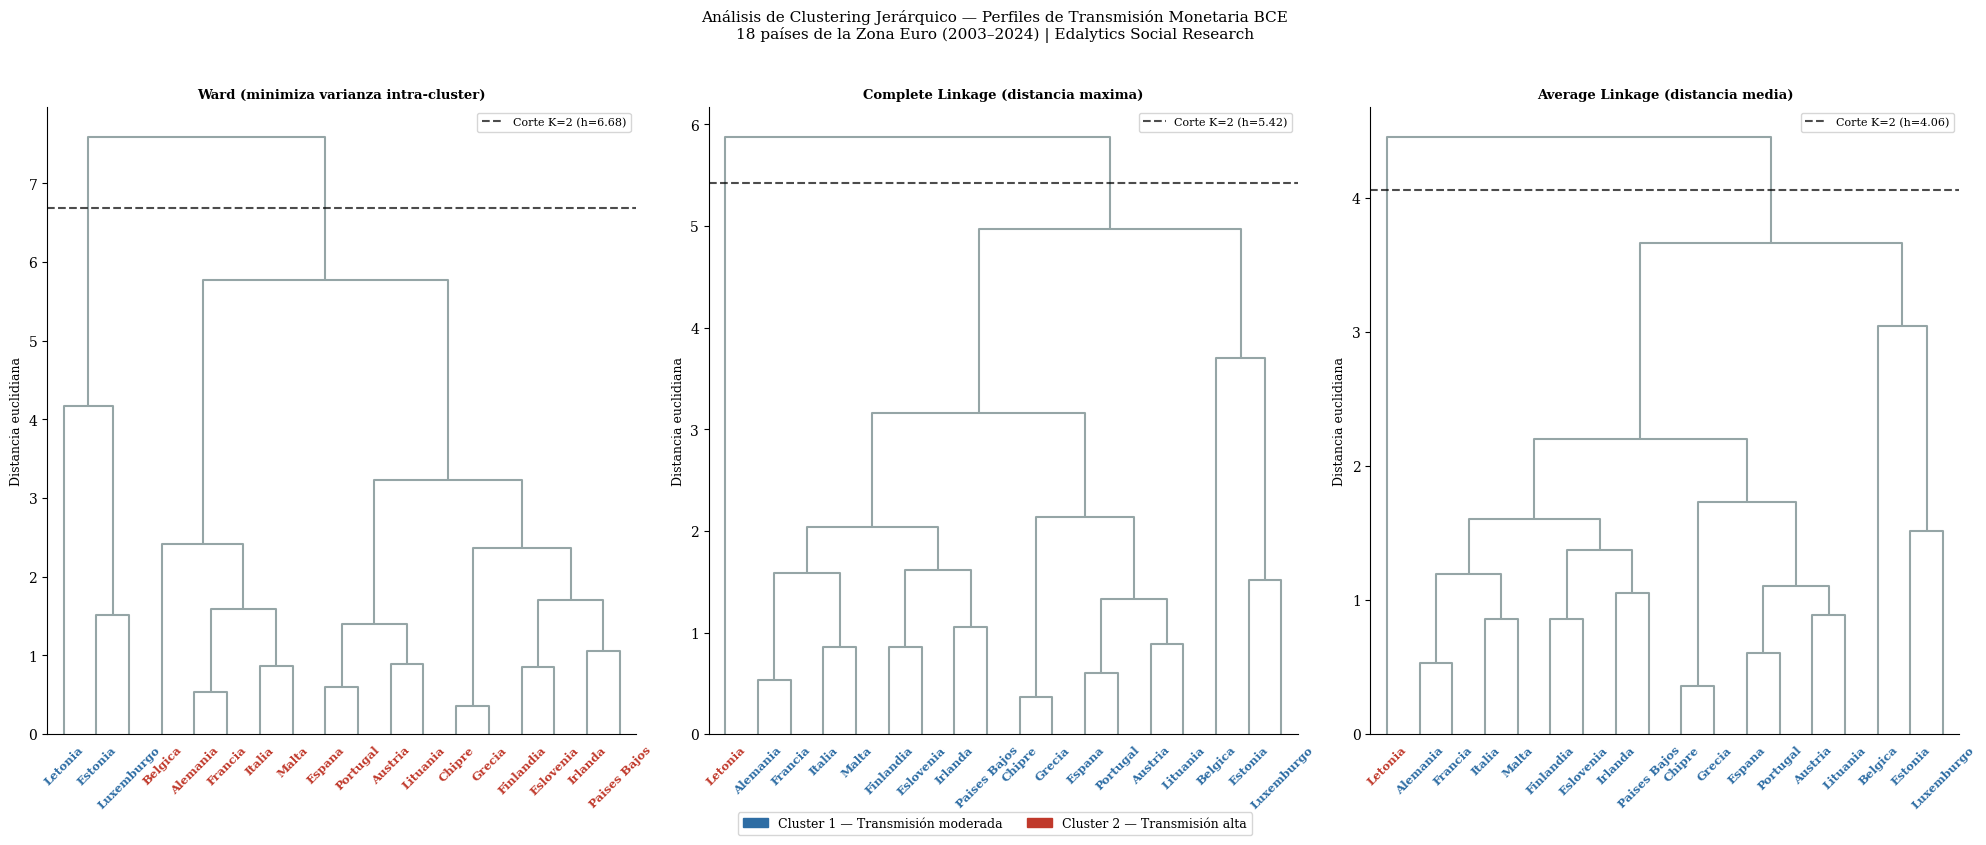

Dendrogramas guardados


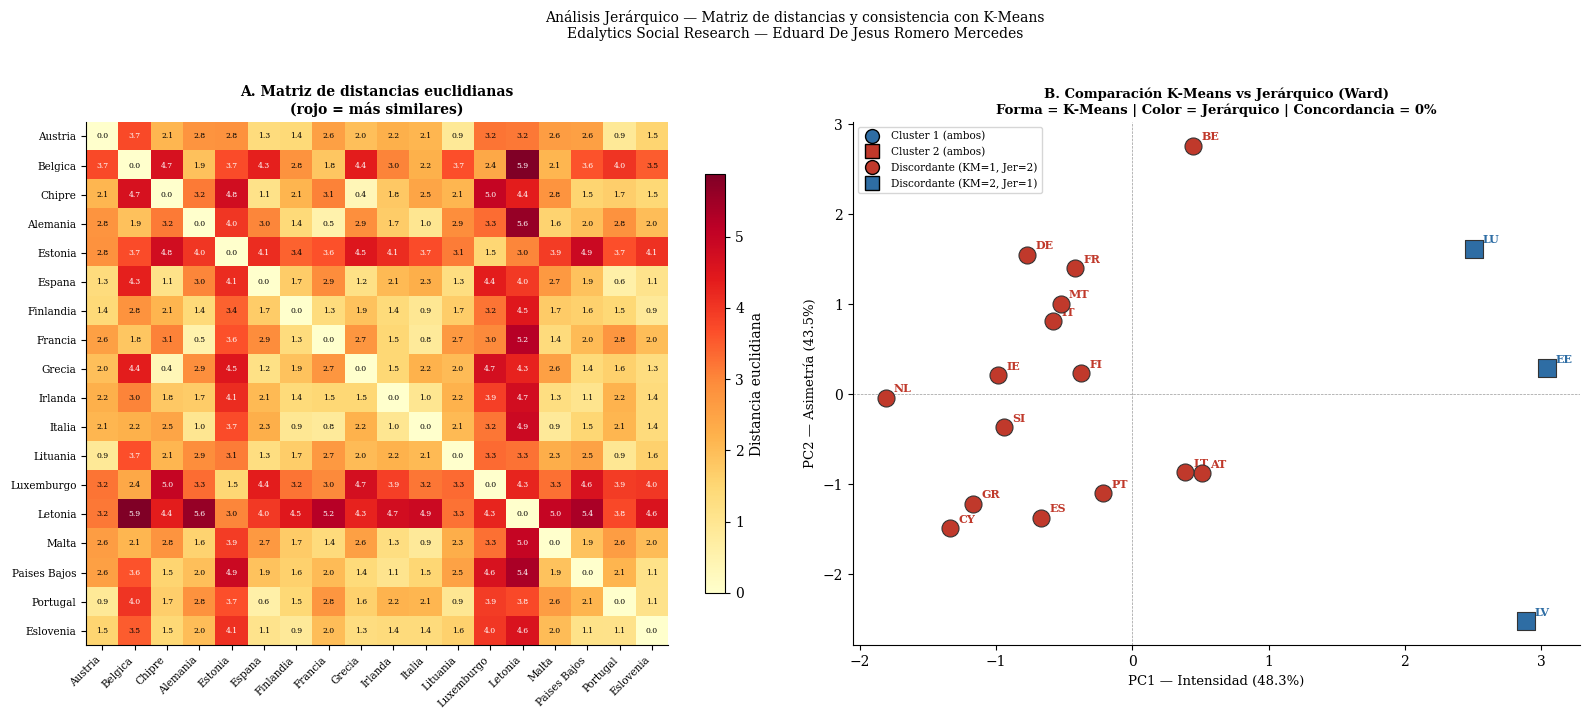

Análisis jerárquico completo guardado

COMPARACION K-MEANS vs JERARQUICO (Ward, K=2)
País                K-Means       Ward     Complete    Average Concordancia
─────────────────────────────────────────────────────────────────
Austria                   1          2            1          1   ~
Belgica                   1          2            1          1   ~
Chipre                    1          2            1          1   ~
Alemania                  1          2            1          1   ~
Estonia                   2          1            1          1   ✓
Espana                    1          2            1          1   ~
Finlandia                 1          2            1          1   ~
Francia                   1          2            1          1   ~
Grecia                    1          2            1          1   ~
Irlanda                   1          2            1          1   ~
Italia                    1          2            1          1   ~
Lituania                  1         

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# ── CLUSTERING JERARQUICO ─────────────────────────────────────────────────────
# Matriz de distancias sobre features estandarizadas
dist_matrix = pdist(X_scaled, metric='euclidean')

# Tres metodos de enlace
metodos = {
    'ward':     'Ward (minimiza varianza intra-cluster)',
    'complete': 'Complete Linkage (distancia maxima)',
    'average':  'Average Linkage (distancia media)',
}

# ── FIGURA: Dendrogramas comparativos ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle(
    'Análisis de Clustering Jerárquico — Perfiles de Transmisión Monetaria BCE\n'
    '18 países de la Zona Euro (2003–2024) | Edalytics Social Research',
    fontsize=11, y=1.02
)

colores_cluster_jerarq = {
    1: C_AZUL,
    2: C_ROJO,
    3: C_VERDE,
    4: C_NAR,
}

resultados_jerarq = {}

for idx, (metodo, titulo) in enumerate(metodos.items()):
    ax = axes[idx]

    # Calcular linkage
    Z = linkage(X_scaled, method=metodo)
    resultados_jerarq[metodo] = Z

    # Asignar clusters con corte en K=2 (consistente con K-Means)
    labels_jerarq = fcluster(Z, t=2, criterion='maxclust')

    # Colorear hojas por cluster
    paises_nombres = df_feat['pais'].tolist()

    def get_leaf_colors(Z, labels, paises):
        leaf_colors = {}
        for i, pais in enumerate(paises):
            cl = labels[i]
            leaf_colors[i] = colores_cluster_jerarq.get(cl, C_GRIS)
        return leaf_colors

    leaf_colors = get_leaf_colors(Z, labels_jerarq, paises_nombres)

    # Funcion de color para dendrogram
    def color_func(k):
        return C_GRIS

    # Dibujar dendrograma
    dn = dendrogram(
        Z,
        labels=paises_nombres,
        ax=ax,
        orientation='top',
        leaf_rotation=45,
        leaf_font_size=8.5,
        color_threshold=0,
        above_threshold_color=C_GRIS,
        link_color_func=lambda k: C_GRIS,
    )

    # Colorear etiquetas de hojas por cluster
    xlbls = ax.get_xmajorticklabels()
    for lbl in xlbls:
        pais = lbl.get_text()
        if pais in paises_nombres:
            idx_pais = paises_nombres.index(pais)
            cl = labels_jerarq[idx_pais]
            lbl.set_color(colores_cluster_jerarq.get(cl, 'black'))
            lbl.set_fontweight('bold')

    # Linea de corte K=2
    # Altura de corte entre el penultimo y ultimo salto
    alturas = sorted(Z[:, 2])
    corte   = (alturas[-1] + alturas[-2]) / 2
    ax.axhline(corte, color='black', lw=1.5, ls='--', alpha=0.7,
               label=f'Corte K=2 (h={corte:.2f})')

    ax.set_title(f'{titulo}', fontsize=9.5, fontweight='bold')
    ax.set_ylabel('Distancia euclidiana', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Leyenda clusters
legend_els = [
    mpatches.Patch(color=C_AZUL, label='Cluster 1 — Transmisión moderada'),
    mpatches.Patch(color=C_ROJO, label='Cluster 2 — Transmisión alta'),
]
fig.legend(handles=legend_els, fontsize=9, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig_dendrogramas.png',
            dpi=160, bbox_inches='tight')
plt.show()
print('Dendrogramas guardados')

# ── FIGURA: Matriz de distancias ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Análisis Jerárquico — Matriz de distancias y consistencia con K-Means\n'
    'Edalytics Social Research — Eduard De Jesus Romero Mercedes',
    fontsize=10, y=1.02
)

# Panel A: Matriz de distancias
ax      = axes[0]
dist_sq = squareform(dist_matrix)
im      = ax.imshow(dist_sq, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(paises_nombres)))
ax.set_yticks(range(len(paises_nombres)))
ax.set_xticklabels(paises_nombres, rotation=45, ha='right', fontsize=7.5)
ax.set_yticklabels(paises_nombres, fontsize=7.5)
ax.set_title('A. Matriz de distancias euclidianas\n(rojo = más similares)',
             fontsize=10, fontweight='bold')

for i in range(len(paises_nombres)):
    for j in range(len(paises_nombres)):
        ax.text(j, i, f'{dist_sq[i,j]:.1f}',
                ha='center', va='center', fontsize=5.5,
                color='white' if dist_sq[i,j] > dist_sq.max()*0.6 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8, label='Distancia euclidiana')

# Panel B: Comparacion K-Means vs Jerarquico (Ward K=2)
ax = axes[1]
Z_ward      = resultados_jerarq['ward']
labels_ward = fcluster(Z_ward, t=2, criterion='maxclust')

# Scatter PC1 vs PC2 con forma=KMeans, color=Jerarquico
markers_km  = ['o', 's']  # circulo=cluster1, cuadrado=cluster2 (KMeans)
colores_jer = {1: C_AZUL, 2: C_ROJO}

concordancia = 0
for i, (_, row) in enumerate(df_feat.iterrows()):
    km_cl  = int(row['cluster'])
    jer_cl = int(labels_ward[i])
    color  = colores_jer.get(jer_cl, C_GRIS)
    marker = markers_km[km_cl]

    ax.scatter(row['PC1'], row['PC2'],
               c=color, marker=marker, s=150,
               zorder=5, edgecolors='#333333', linewidths=0.8)
    ax.annotate(row['cod'], (row['PC1'], row['PC2']),
                textcoords='offset points', xytext=(6,4),
                fontsize=8, fontweight='bold', color=color)

    # Verificar concordancia
    if km_cl == jer_cl-1:
        concordancia += 1

ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.axvline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.set_xlabel(f'PC1 — Intensidad ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=9.5)
ax.set_ylabel(f'PC2 — Asimetría ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=9.5)

pct_concordancia = concordancia / len(df_feat) * 100
ax.set_title(f'B. Comparación K-Means vs Jerárquico (Ward)\n'
             f'Forma = K-Means | Color = Jerárquico | '
             f'Concordancia = {pct_concordancia:.0f}%',
             fontsize=9.5, fontweight='bold')

legend_els2 = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_AZUL,
           markeredgecolor='black', markersize=10, label='Cluster 1 (ambos)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=C_ROJO,
           markeredgecolor='black', markersize=10, label='Cluster 2 (ambos)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_ROJO,
           markeredgecolor='black', markersize=10, label='Discordante (KM=1, Jer=2)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=C_AZUL,
           markeredgecolor='black', markersize=10, label='Discordante (KM=2, Jer=1)'),
]
ax.legend(handles=legend_els2, fontsize=7.5, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig_jerarquico_completo.png',
            dpi=160, bbox_inches='tight')
plt.show()
print('Análisis jerárquico completo guardado')

# ── TABLA DE ASIGNACION DE CLUSTERS ──────────────────────────────────────────
print('\nCOMPARACION K-MEANS vs JERARQUICO (Ward, K=2)')
print('='*65)
print(f'{"País":<16} {"K-Means":>10} {"Ward":>10} {"Complete":>12} {"Average":>10} {"Concordancia"}')
print('─'*65)

labels_complete = fcluster(resultados_jerarq['complete'], t=2, criterion='maxclust')
labels_average  = fcluster(resultados_jerarq['average'],  t=2, criterion='maxclust')

for i, (_, row) in enumerate(df_feat.iterrows()):
    km = int(row['cluster']) + 1
    w  = int(labels_ward[i])
    c  = int(labels_complete[i])
    a  = int(labels_average[i])
    concordante = '✓' if (w==c==a) else '~'
    print(f'{row["pais"]:<16} {km:>10} {w:>10} {c:>12} {a:>10}   {concordante}')

# Calcular concordancia global
total = len(df_feat)
conc  = sum(1 for i in range(total)
            if labels_ward[i]==labels_complete[i]==labels_average[i])
print(f'\nConcordancia total (Ward=Complete=Average): {conc}/{total} ({conc/total*100:.0f}%)')

COMPARACION CORREGIDA K-MEANS vs JERARQUICO (K=2)
Pais                K-Means     Ward   Complete   Average Acuerdo
──────────────────────────────────────────────────────────────────────
Austria                   1        1          1         1   ✓ Todos
Belgica                   1        1          1         1   ✓ Todos
Chipre                    1        1          1         1   ✓ Todos
Alemania                  1        1          1         1   ✓ Todos
Estonia                   2        2          1         1   ✗ Discordante
Espana                    1        1          1         1   ✓ Todos
Finlandia                 1        1          1         1   ✓ Todos
Francia                   1        1          1         1   ✓ Todos
Grecia                    1        1          1         1   ✓ Todos
Irlanda                   1        1          1         1   ✓ Todos
Italia                    1        1          1         1   ✓ Todos
Lituania                  1        1          1         1  

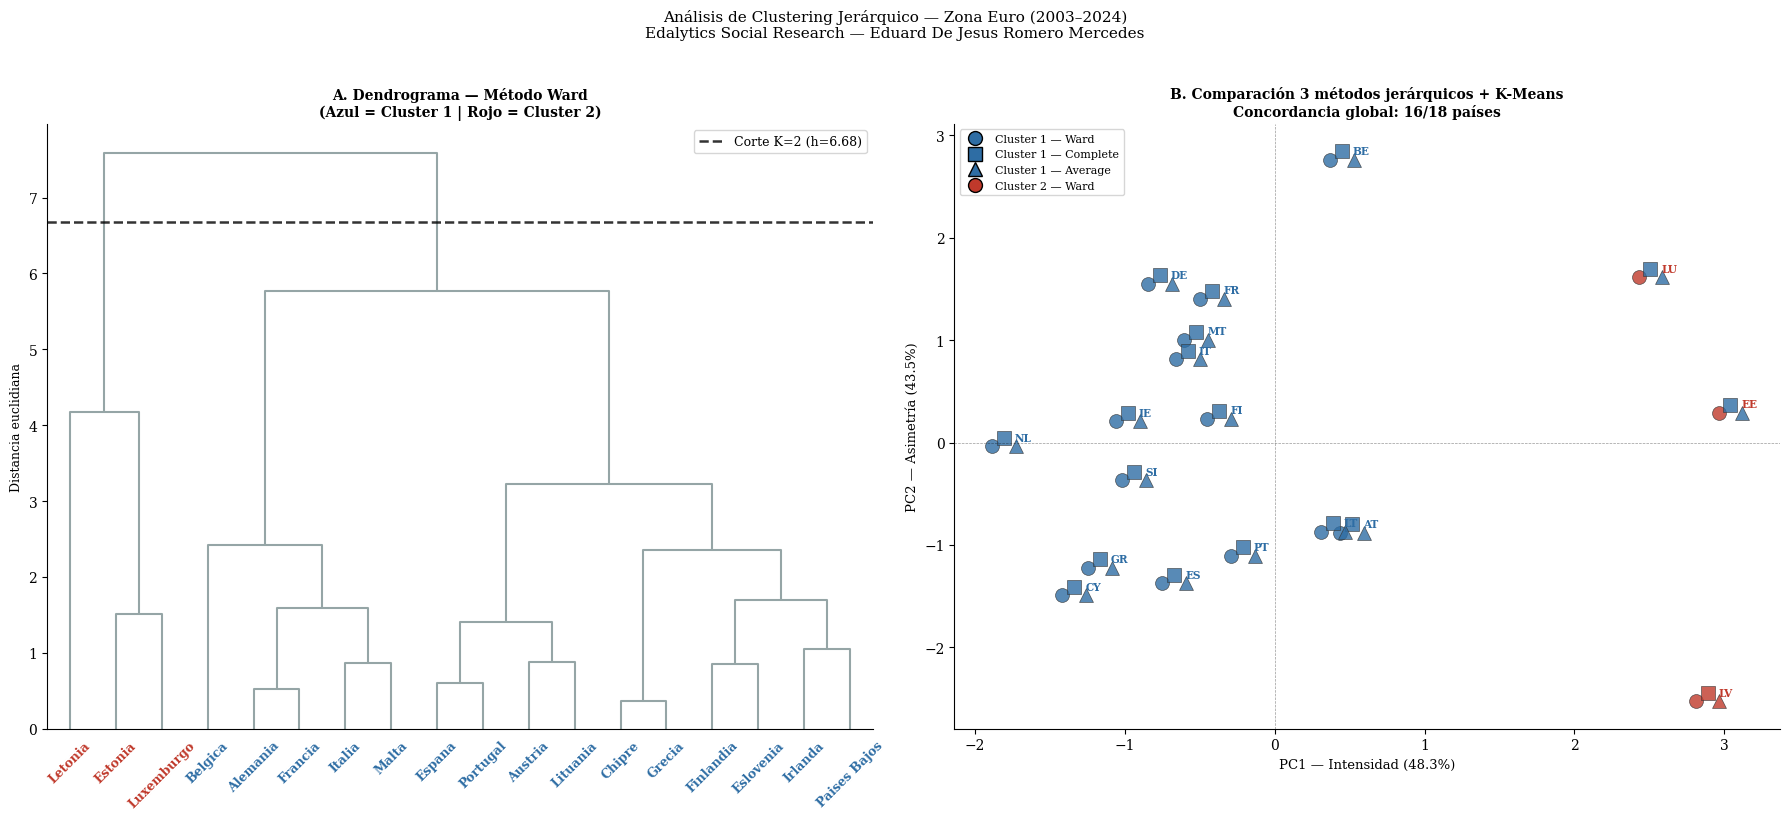

Figura jerárquica definitiva guardada


In [19]:
# ── CORRECCION DE ETIQUETAS ───────────────────────────────────────────────────
# Ward invierte las etiquetas respecto a K-Means
# Corregimos remapeando Ward: 1→2, 2→1

def remap_labels(labels, ref_labels):
    """
    Remapea labels para maximizar concordancia con ref_labels.
    Prueba todas las permutaciones posibles de etiquetas.
    """
    from itertools import permutations
    unique = sorted(set(labels))
    best_map   = {k:k for k in unique}
    best_conc  = 0
    for perm in permutations(unique):
        mapping = dict(zip(unique, perm))
        mapped  = [mapping[l] for l in labels]
        conc    = sum(m==r for m,r in zip(mapped, ref_labels))
        if conc > best_conc:
            best_conc = conc
            best_map  = mapping
    return [best_map[l] for l in labels], best_conc

# Labels K-Means como referencia (1-indexed)
km_labels = (df_feat['cluster'] + 1).tolist()

# Recalcular concordancias con remapeo
labels_ward_r,     conc_w = remap_labels(list(labels_ward),     km_labels)
labels_complete_r, conc_c = remap_labels(list(labels_complete), km_labels)
labels_average_r,  conc_a = remap_labels(list(labels_average),  km_labels)

print('COMPARACION CORREGIDA K-MEANS vs JERARQUICO (K=2)')
print('='*70)
print(f'{"Pais":<16} {"K-Means":>10} {"Ward":>8} {"Complete":>10} {"Average":>9} {"Acuerdo"}')
print('─'*70)

for i, (_, row) in enumerate(df_feat.iterrows()):
    km = km_labels[i]
    w  = labels_ward_r[i]
    c  = labels_complete_r[i]
    a  = labels_average_r[i]
    acuerdo = '✓ Todos' if km==w==c==a else \
              ('~ Parcial' if sum([km==w, km==c, km==a])>=2 else '✗ Discordante')
    print(f'{row["pais"]:<16} {km:>10} {w:>8} {c:>10} {a:>9}   {acuerdo}')

total = len(df_feat)
conc_total = sum(1 for i in range(total)
                 if labels_ward_r[i]==labels_complete_r[i]==labels_average_r[i]==km_labels[i])
print(f'\nConcordancia total (los 4 metodos): {conc_total}/{total} ({conc_total/total*100:.0f}%)')
print(f'Concordancia Ward vs K-Means      : {conc_w}/{total} ({conc_w/total*100:.0f}%)')
print(f'Concordancia Complete vs K-Means  : {conc_c}/{total} ({conc_c/total*100:.0f}%)')
print(f'Concordancia Average vs K-Means   : {conc_a}/{total} ({conc_a/total*100:.0f}%)')

# ── FIGURA DEFINITIVA: Dendrograma Ward + Matriz de distancias ────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'Análisis de Clustering Jerárquico — Zona Euro (2003–2024)\n'
    'Edalytics Social Research — Eduard De Jesus Romero Mercedes',
    fontsize=11, y=1.02
)

# Panel A: Dendrograma Ward (el más robusto)
ax = axes[0]
Z_ward = resultados_jerarq['ward']

colores_hojas = {1: C_AZUL, 2: C_ROJO}

dn = dendrogram(
    Z_ward,
    labels=df_feat['pais'].tolist(),
    ax=ax,
    orientation='top',
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color=C_GRIS,
    link_color_func=lambda k: C_GRIS,
)

# Colorear etiquetas por cluster corregido
for lbl, cl in zip(ax.get_xmajorticklabels(), 
                   [labels_ward_r[df_feat['pais'].tolist().index(t.get_text())]
                    for t in ax.get_xmajorticklabels()]):
    lbl.set_color(colores_hojas.get(cl, 'black'))
    lbl.set_fontweight('bold')

# Linea de corte
alturas = sorted(Z_ward[:, 2])
corte   = (alturas[-1] + alturas[-2]) / 2
ax.axhline(corte, color='black', lw=1.8, ls='--', alpha=0.8,
           label=f'Corte K=2 (h={corte:.2f})')

ax.set_title('A. Dendrograma — Método Ward\n'
             '(Azul = Cluster 1 | Rojo = Cluster 2)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Distancia euclidiana', fontsize=9)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel B: Scatter comparativo 3 metodos
ax = axes[1]
markers_method = {'Ward':'o', 'Complete':'s', 'Average':'^'}
labels_all     = {
    'Ward':     labels_ward_r,
    'Complete': labels_complete_r,
    'Average':  labels_average_r,
}

offsets = {'Ward': (-0.08, 0), 'Complete': (0, 0.08), 'Average': (0.08, 0)}

for method, labs in labels_all.items():
    for i, (_, row) in enumerate(df_feat.iterrows()):
        cl    = labs[i]
        color = colores_hojas.get(cl, C_GRIS)
        dx, dy = offsets[method]
        ax.scatter(row['PC1']+dx, row['PC2']+dy,
                   c=color, marker=markers_method[method],
                   s=100, alpha=0.8, edgecolors='#333333', linewidths=0.5)

# Etiquetas de paises (solo una vez, sin offset)
for _, row in df_feat.iterrows():
    ax.annotate(row['cod'], (row['PC1'], row['PC2']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=7.5, fontweight='bold',
                color=colores_hojas.get(labels_ward_r[df_feat.index.get_loc(row.name)], 'black'))

ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.axvline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.set_xlabel(f'PC1 — Intensidad ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=9.5)
ax.set_ylabel(f'PC2 — Asimetría ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=9.5)
ax.set_title(f'B. Comparación 3 métodos jerárquicos + K-Means\n'
             f'Concordancia global: {conc_total}/{total} países',
             fontsize=10, fontweight='bold')

legend_els = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor=C_AZUL,
           markeredgecolor='black',markersize=10,label='Cluster 1 — Ward'),
    Line2D([0],[0],marker='s',color='w',markerfacecolor=C_AZUL,
           markeredgecolor='black',markersize=10,label='Cluster 1 — Complete'),
    Line2D([0],[0],marker='^',color='w',markerfacecolor=C_AZUL,
           markeredgecolor='black',markersize=10,label='Cluster 1 — Average'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=C_ROJO,
           markeredgecolor='black',markersize=10,label='Cluster 2 — Ward'),
]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig_jerarquico_definitivo.png',
            dpi=160, bbox_inches='tight')
plt.show()
print('Figura jerárquica definitiva guardada')

In [20]:
# ── ANALISIS EXCLUYENDO OUTLIERS: Luxemburgo, Letonia, Estonia ────────────────
excluir = ['Luxemburgo', 'Letonia', 'Estonia']

df_feat_sin = df_feat[~df_feat['pais'].isin(excluir)].copy().reset_index(drop=True)
X_scaled_sin = scaler.fit_transform(df_feat_sin[features].values)

print(f"Paises incluidos: {len(df_feat_sin)}")
print(f"Excluidos: {excluir}")
print(f"\nMatriz features sin outliers:")
print(df_feat_sin.set_index('pais')[features].round(3).to_string())

# ── PCA ───────────────────────────────────────────────────────────────────────
pca_sin   = PCA(n_components=4)
X_pca_sin = pca_sin.fit_transform(X_scaled_sin)
X2_sin    = X_pca_sin[:, :2]

print('\nPCA SIN OUTLIERS')
print('='*45)
print(f'{"Componente":<12} {"Varianza":>10} {"Acumulada":>12}')
print('─'*36)
acum = 0
for i, var in enumerate(pca_sin.explained_variance_ratio_):
    acum += var
    print(f'PC{i+1:<10} {var*100:>9.2f}% {acum*100:>11.2f}%')

print('\nLoadings:')
df_load_sin = pd.DataFrame(
    pca_sin.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(4)]
).round(3)
print(df_load_sin)

# ── K OPTIMO ──────────────────────────────────────────────────────────────────
print('\nSELECCION K OPTIMO SIN OUTLIERS')
sil_sin = {}
for k in range(2, 7):
    km_t  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl   = km_t.fit_predict(X2_sin)
    if len(set(lbl)) > 1:
        sil_sin[k] = silhouette_score(X2_sin, lbl)
        print(f'  K={k}: silhouette={sil_sin[k]:.4f}')

k_opt_sin = max(sil_sin, key=sil_sin.get)
print(f'\nK optimo: {k_opt_sin} (Silhouette={sil_sin[k_opt_sin]:.4f})')

# ── KMEANS FINAL SIN OUTLIERS ─────────────────────────────────────────────────
km_sin = KMeans(n_clusters=k_opt_sin, random_state=42, n_init=10)
df_feat_sin['cluster'] = km_sin.fit_predict(X2_sin)
df_feat_sin['PC1']     = X_pca_sin[:, 0]
df_feat_sin['PC2']     = X_pca_sin[:, 1]

print(f'\nCLUSTERS SIN OUTLIERS (K={k_opt_sin})')
print('='*60)
for c in range(k_opt_sin):
    paises_c = df_feat_sin[df_feat_sin['cluster']==c]['pais'].tolist()
    medias   = df_feat_sin[df_feat_sin['cluster']==c][features].mean()
    print(f'\nCluster {c+1} ({len(paises_c)} paises): {", ".join(paises_c)}')
    print(f'  PT_Eur_Hip={medias["PT_Eur_Hip"]:.3f} | PT_Eur_Dep={medias["PT_Eur_Dep"]:.3f}')
    print(f'  PT_MRO_Hip={medias["PT_MRO_Hip"]:.3f} | PT_MRO_Dep={medias["PT_MRO_Dep"]:.3f}')

Paises incluidos: 15
Excluidos: ['Luxemburgo', 'Letonia', 'Estonia']

Matriz features sin outliers:
              PT_MRO_Hip  PT_MRO_Dep  PT_Eur_Hip  PT_Eur_Dep
pais                                                        
Austria            0.453       0.486       0.637       0.452
Belgica           -0.013       1.020       0.144       0.747
Chipre             0.413       0.208       0.409       0.125
Alemania           0.012       0.544       0.168       0.615
Espana             0.312       0.321       0.598       0.225
Finlandia          0.194       0.456       0.406       0.508
Francia            0.150       0.601       0.167       0.608
Grecia             0.431       0.243       0.373       0.187
Irlanda            0.293       0.489       0.189       0.318
Italia             0.134       0.605       0.261       0.452
Lituania           0.377       0.629       0.640       0.312
Malta              0.135       0.783       0.205       0.354
Paises Bajos       0.097       0.305       0.2

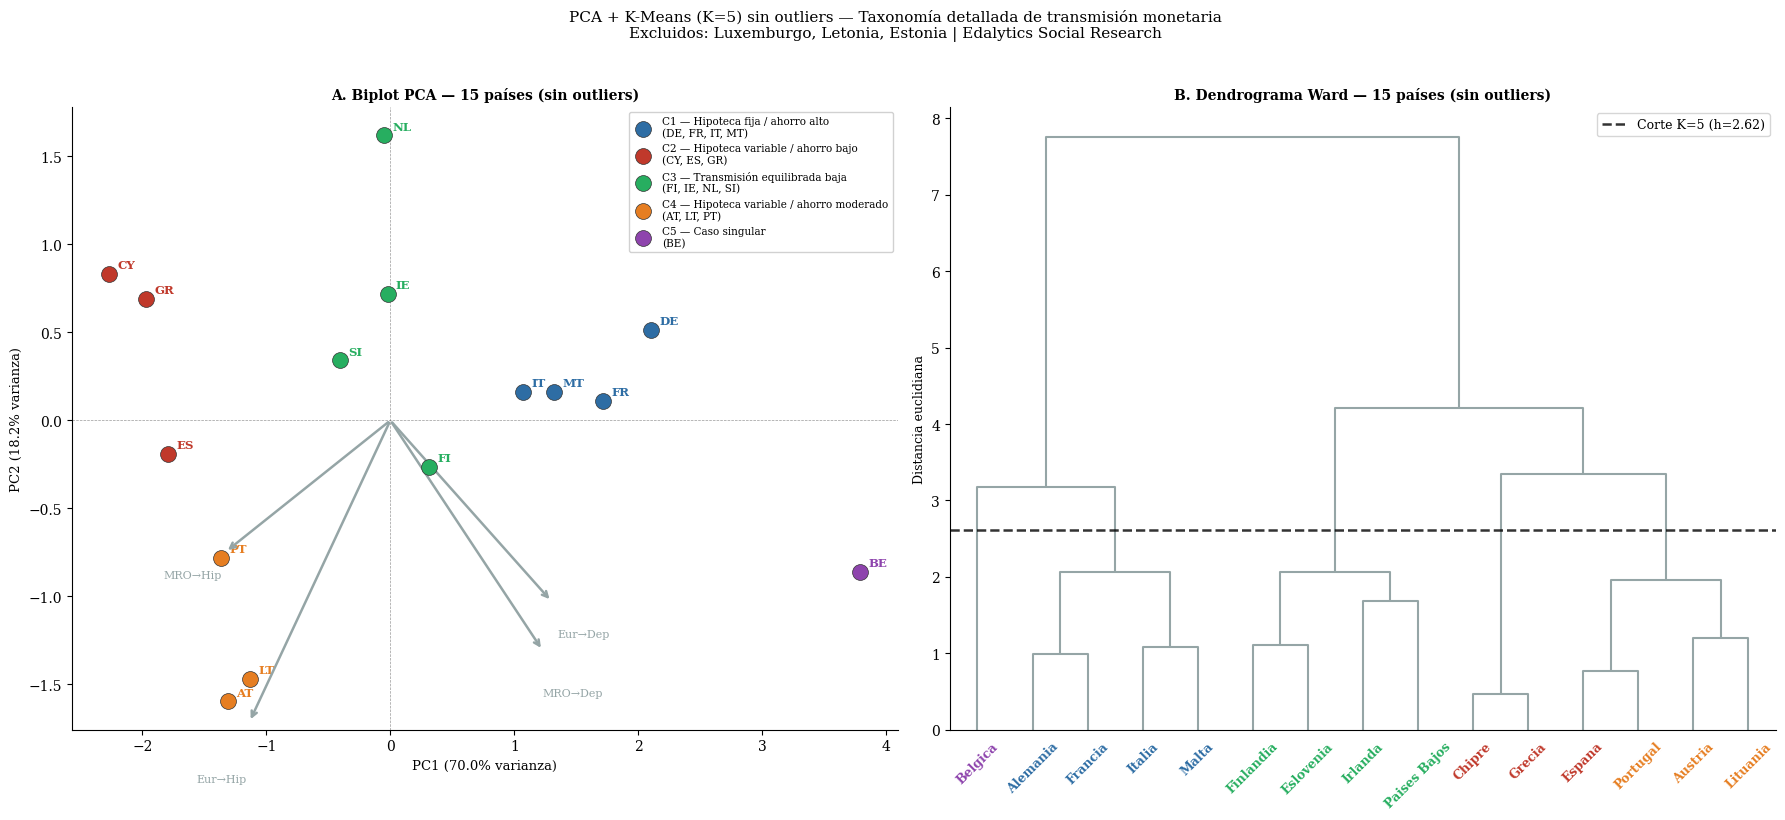

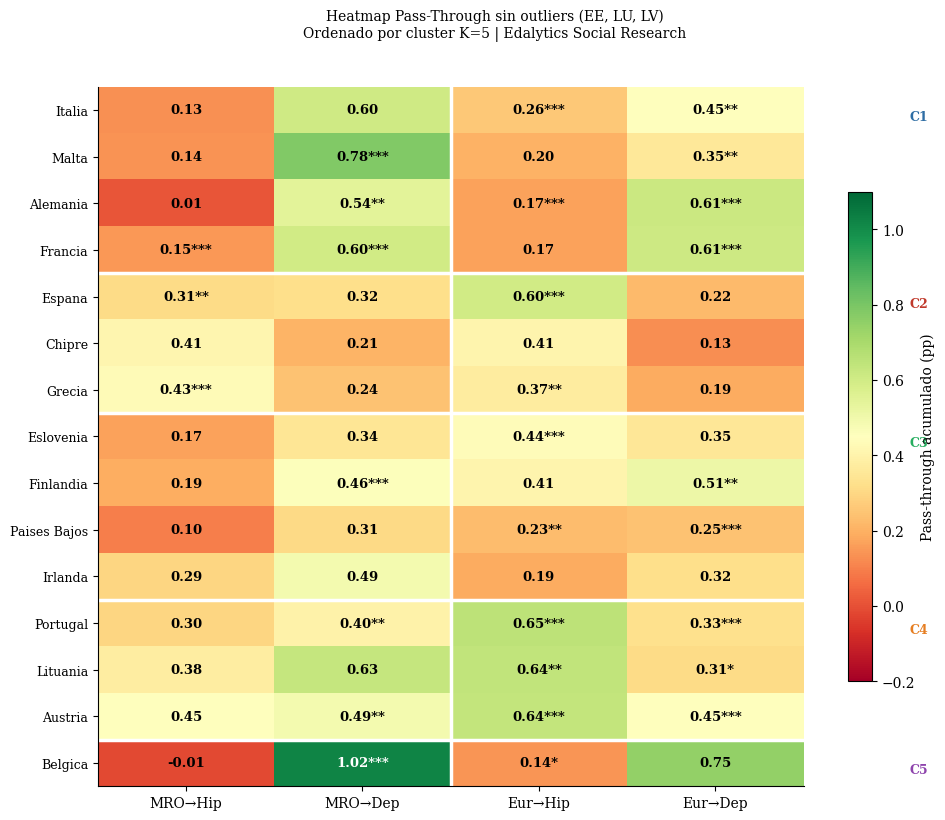

Figuras sin outliers guardadas


In [21]:
# ── FIGURA: PCA + Clusters sin outliers ───────────────────────────────────────
colores_5cl = {
    0: C_AZUL,
    1: C_ROJO,
    2: C_VERDE,
    3: C_NAR,
    4: '#8e44ad',
}
nombres_5cl = {
    0: 'C1 — Hipoteca fija / ahorro alto\n(DE, FR, IT, MT)',
    1: 'C2 — Hipoteca variable / ahorro bajo\n(CY, ES, GR)',
    2: 'C3 — Transmisión equilibrada baja\n(FI, IE, NL, SI)',
    3: 'C4 — Hipoteca variable / ahorro moderado\n(AT, LT, PT)',
    4: 'C5 — Caso singular\n(BE)',
}

fig = plt.figure(figsize=(18, 8))
fig.suptitle(
    'PCA + K-Means (K=5) sin outliers — Taxonomía detallada de transmisión monetaria\n'
    'Excluidos: Luxemburgo, Letonia, Estonia | Edalytics Social Research',
    fontsize=11, y=1.02
)

# Panel A: Biplot
ax = fig.add_subplot(121)
etiq = {'PT_MRO_Hip':'MRO→Hip','PT_MRO_Dep':'MRO→Dep',
        'PT_Eur_Hip':'Eur→Hip','PT_Eur_Dep':'Eur→Dep'}

for c in range(k_opt_sin):
    mask = df_feat_sin['cluster'] == c
    ax.scatter(df_feat_sin[mask]['PC1'], df_feat_sin[mask]['PC2'],
               c=colores_5cl[c], s=130, zorder=5,
               label=nombres_5cl[c], edgecolors='#333333', linewidths=0.5)
    for _, row in df_feat_sin[mask].iterrows():
        ax.annotate(row['cod'], (row['PC1'], row['PC2']),
                    textcoords='offset points', xytext=(6,4),
                    fontsize=8.5, fontweight='bold', color=colores_5cl[c])

# Flechas loadings
scale = 2.5
for i, feat in enumerate(features):
    ax.annotate('',
        xy=(pca_sin.components_[0,i]*scale, pca_sin.components_[1,i]*scale),
        xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color=C_GRIS, lw=1.8))
    ax.text(pca_sin.components_[0,i]*scale*1.2,
            pca_sin.components_[1,i]*scale*1.2,
            etiq[feat], fontsize=8, color=C_GRIS, ha='center')

ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.axvline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax.set_xlabel(f'PC1 ({pca_sin.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=9.5)
ax.set_ylabel(f'PC2 ({pca_sin.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=9.5)
ax.set_title('A. Biplot PCA — 15 países (sin outliers)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5, loc='upper right', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel B: Dendrograma jerárquico sin outliers
ax = fig.add_subplot(122)
Z_sin = linkage(X_scaled_sin, method='ward')

# Colorear hojas por cluster
paises_sin = df_feat_sin['pais'].tolist()
cluster_sin = df_feat_sin['cluster'].tolist()

dn = dendrogram(
    Z_sin,
    labels=paises_sin,
    ax=ax,
    orientation='top',
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=0,
    above_threshold_color=C_GRIS,
    link_color_func=lambda k: C_GRIS,
)

for lbl in ax.get_xmajorticklabels():
    pais = lbl.get_text()
    if pais in paises_sin:
        cl = cluster_sin[paises_sin.index(pais)]
        lbl.set_color(colores_5cl.get(cl, 'black'))
        lbl.set_fontweight('bold')

alturas_sin = sorted(Z_sin[:, 2])
corte_sin   = (alturas_sin[-4] + alturas_sin[-5]) / 2
ax.axhline(corte_sin, color='black', lw=1.8, ls='--', alpha=0.8,
           label=f'Corte K=5 (h={corte_sin:.2f})')

ax.set_title('B. Dendrograma Ward — 15 países (sin outliers)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Distancia euclidiana', fontsize=9)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig_pca_sin_outliers.png',
            dpi=160, bbox_inches='tight')
plt.show()

# ── FIGURA: Heatmap de pass-through sin outliers ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(
    'Heatmap Pass-Through sin outliers (EE, LU, LV)\n'
    'Ordenado por cluster K=5 | Edalytics Social Research',
    fontsize=10, y=1.02
)

# Ordenar por cluster
df_ord = df_feat_sin.sort_values(['cluster','PT_Eur_Hip'], ascending=[True,False])
paises_ord_sin = df_ord['pais'].tolist()
canales_hm     = ['MRO→Hip','MRO→Dep','Eur→Hip','Eur→Dep']
canales_key    = [('mro','hipoteca_nueva'),('mro','depositos'),
                  ('euribor_12m','hipoteca_nueva'),('euribor_12m','depositos')]

matriz_sin = np.zeros((len(paises_ord_sin), 4))
sigs_sin   = [['' for _ in range(4)] for _ in paises_ord_sin]

for j, (xv, yv) in enumerate(canales_key):
    for i, pais in enumerate(paises_ord_sin):
        cod = df_ze[df_ze['pais']==pais]['cod'].iloc[0]
        r   = df_ze[(df_ze['cod']==cod)&(df_ze['canal']==f'{xv} → {yv}')]
        if len(r)>0:
            matriz_sin[i,j]   = r['efecto_acum'].values[0]
            sigs_sin[i][j]    = r['sig'].values[0]

im = ax.imshow(matriz_sin, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=1.1)
for i in range(len(paises_ord_sin)):
    for j in range(4):
        col = 'white' if abs(matriz_sin[i,j])>0.85 else 'black'
        ax.text(j, i, f'{matriz_sin[i,j]:.2f}{sigs_sin[i][j]}',
                ha='center', va='center', fontsize=9.5, fontweight='bold', color=col)

# Lineas separadoras de clusters
cl_actual = df_ord['cluster'].values
for i in range(1, len(cl_actual)):
    if cl_actual[i] != cl_actual[i-1]:
        ax.axhline(i-0.5, color='white', lw=2.5)

# Etiquetas de cluster en el lateral
cl_labels = []
prev_cl = -1
for i, cl in enumerate(cl_actual):
    if cl != prev_cl:
        cl_labels.append((i, f'C{cl+1}'))
        prev_cl = cl

for pos, lbl in cl_labels:
    ax.text(4.1, pos, lbl, va='top', fontsize=9, fontweight='bold',
            color=colores_5cl.get(int(lbl[1])-1, 'black'))

ax.set_xticks(range(4))
ax.set_xticklabels(canales_hm, fontsize=10)
ax.set_yticks(range(len(paises_ord_sin)))
ax.set_yticklabels(paises_ord_sin, fontsize=9)
ax.axvline(1.5, color='white', lw=2.5)
plt.colorbar(im, ax=ax, shrink=0.7, label='Pass-through acumulado (pp)')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/outputs/figures/fig_heatmap_sin_outliers.png',
            dpi=160, bbox_inches='tight')
plt.show()
print('Figuras sin outliers guardadas')